In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import os
from utils_indicators import *
from plot_optimization import *
import pickle


**compute climate classfication & demand**

In [4]:
new_directory = "/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/BayesDPS_Nnet"
os.chdir(new_directory)
print(os.getcwd())

/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/BayesDPS_Nnet


In [3]:
from Config import *
#from pipe_simulation import *
 


Test and classify climates, make deficit plots and require capacity!

In [4]:
#read in inflow
climate_label = 'test4'
inflows = pd.read_csv(f'data/Annual_GPR/{climate_label}_runoff.csv',header= None).T/12 
inflows

,0,1,2,3,4,5,6,7,8,9,...,590,591,592,593,594,595,596,597,598,599
0,2.987082,2.535533,3.473668,4.431962,4.464788,2.279971,3.089399,2.902310,4.230505,3.370252,...,4.484997,4.707729,4.942264,9.662273,3.547746,4.734977,6.352741,4.044063,9.717878,3.844492
1,2.694537,5.625777,2.840118,6.079956,4.367010,2.764539,3.358034,2.298238,3.975353,2.928988,...,4.435650,2.989639,4.469897,5.960101,2.737695,3.577423,3.456272,4.945900,7.551544,2.868539
2,2.364428,3.638260,3.447313,6.697406,3.341600,1.962714,2.733479,2.699039,3.264505,3.118315,...,3.213292,3.297168,3.305423,7.070879,2.213897,3.604310,2.891830,4.623137,7.613172,2.274604
3,6.258939,6.278301,4.823959,6.022193,2.807580,2.117874,3.568151,3.932356,3.856982,7.078132,...,3.339290,3.418844,4.194806,4.601810,2.732298,3.656940,4.267031,5.462649,5.985015,2.969762
4,13.643731,4.116913,6.834379,5.435249,3.045168,3.054952,3.282371,3.772292,3.530732,6.132512,...,4.062815,6.609859,4.118195,7.997287,4.527424,3.458282,5.816159,5.415828,5.220043,5.083370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2.066607,1.130036,3.529583,1.133521,0.816200,1.198115,1.425100,2.493587,1.453620,1.219511,...,2.090135,2.584125,4.486544,2.543579,2.091457,2.791854,4.088971,1.810347,3.277060,3.453051
1196,1.582685,2.024584,3.198929,1.335343,0.736652,1.052651,2.010418,2.364852,1.492375,1.750413,...,1.598456,2.493360,4.196255,4.540094,1.740817,2.888613,2.870066,1.830971,3.759627,3.183115
1197,2.130088,3.516353,3.483344,9.002126,2.298260,3.195538,4.554019,2.617991,1.524630,4.051659,...,1.611812,9.405964,4.504275,4.152516,9.879472,8.311600,3.655412,4.402047,14.118391,3.326046
1198,3.868980,4.482754,4.910906,8.537088,4.667981,3.010717,3.834765,3.626043,4.348216,3.548652,...,5.170922,9.145546,6.427615,12.874138,6.582454,7.513712,6.385723,5.484045,28.250063,4.884847


In [5]:
# compute MAR: mean annual runoff
MAR = inflows.mean().values[0]
MAR

3.703734562034393

Simulate reservoir operation under inflows. compute deficit over time


In [6]:
def nsim_equiv_res(s, u, n, s_max):
    # extremely fast reservoir mass balance computation
    r         = max(0, min(u, s))
    s_        = s + n - r
    s_        = max(0, min(s_, s_max ))

    return s_, r


class ReservoirSimulation:
    def __init__(self, hedge_param, smax):
        self.hedge_param = hedge_param
        self.smax = smax

    def operate(self, s_next, demand_, inflow):
        hedge = self.hedge_param * s_next
        flood = 10 * s_next * (1 / 2 - demand_ / self.smax) - 9 * (self.smax / 2 - demand_) + demand_
        u = max(min(hedge, demand_), flood)

        # Reservoir mass balance
        s_current = s_next
        s_next, release = nsim_equiv_res(s_next, u, inflow, self.smax,)
        is_balance_correct = 1 if np.isclose(s_current + inflow - release, s_next) else 0
       
        water_def = max(0, demand_ - release)
        if water_def < 1e-4:
            water_def = 0

        return s_next, release, water_def,is_balance_correct

Simulate reservoir to achieve water deficit without adding additional capacity 

In [7]:
def classify_climates(inflows, nsim):
    H = 1200
    demand = np.ones(H) * 5
    hedge_param = 15
    smax = 60
    initial_storage = 45

    # Create a simulation object
    res_simulation = ReservoirSimulation(hedge_param, smax)

    deficit_list = []
    climate_classification = []

    for i in nsim:
        inflow = inflows.iloc[:, i].values 
        classified = False

        for w in np.array([0, 0.5, 1, 1.5, 2,2.5]):
            # Initialize arrays
            s_next = np.zeros(H + 1)  # storage
            s_next[0] = initial_storage
            r = np.zeros(H)
            deficit = np.zeros(H)
            balance = np.zeros(H)

            # Run the simulation
            for t in range(H):
                demand_ = demand[t] - w
                s_next[t + 1], r[t], deficit[t], balance[t] = res_simulation.operate(s_next[t], demand_, inflow[t])

            # Calculate mean annual deficit
            mean_annual_deficit = np.mean(deficit.reshape(-1, 12), axis=1)
            if w == 0:
                initial_deficit = mean_annual_deficit

            if np.sum(mean_annual_deficit[5:]) == 0:
                climate_classification.append(w)
                classified = True
                break
        
        if not classified:
            climate_classification.append(4)

        deficit_list.append(initial_deficit)

    return np.array(deficit_list), np.array(climate_classification)


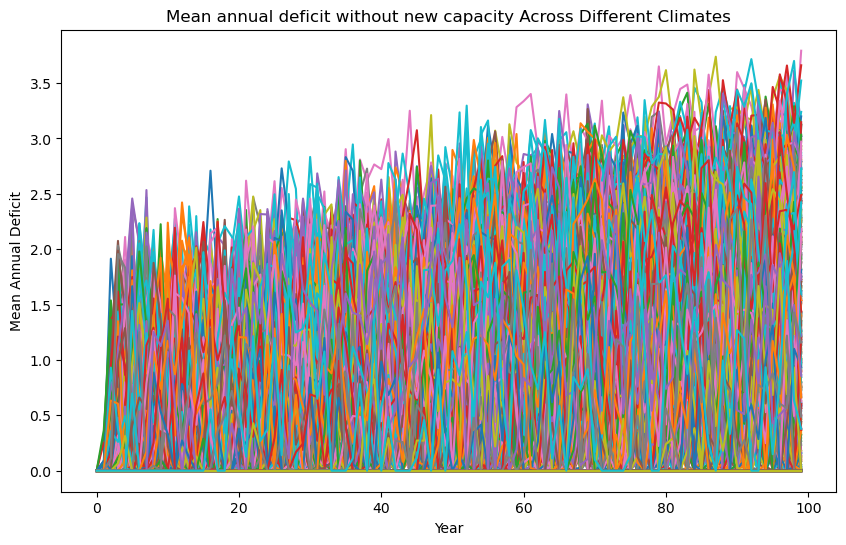

In [8]:
n_models = inflows.shape[1]
nsim = np.arange(0, n_models)

deficit_array, climate_classes = classify_climates(inflows, nsim)

# Plotting the deficit for w=0
plt.figure(figsize=(10, 6))
for i in np.arange(0,600):
    plt.plot(deficit_array[i], label=f'Climate {i}')

plt.xlabel('Year')
plt.ylabel('Mean Annual Deficit')
plt.title('Mean annual deficit without new capacity Across Different Climates')
#plt.legend()
plt.show()


In [9]:
# Compute the number of climates in each classification
unique, counts = np.unique(climate_classes, return_counts=True)
climate_counts = dict(zip(unique, counts))
climate_counts
# compute and print the id of the climate in each classification (unique)





{0.0: 104, 0.5: 121, 1.0: 132, 1.5: 92, 2.0: 71, 2.5: 61, 4.0: 19}

In [10]:
climate_indices = {}

# Iterate over the climate_classes array with index
for index, c_class in enumerate(climate_classes):
    if c_class in climate_indices:
        climate_indices[c_class].append(index)
    else:
        climate_indices[c_class] = [index]

#
# Print the indices 
for c_class in climate_indices:
    print(f"Climate Classification {c_class}: Indices {climate_indices[c_class]}")

Climate Classification 2.0: Indices [0, 3, 7, 8, 10, 11, 14, 16, 24, 25, 31, 32, 35, 41, 42, 45, 46, 57, 60, 67, 69, 72, 87, 93, 95, 104, 110, 112, 119, 120, 122, 124, 134, 146, 147, 151, 155, 156, 157, 159, 164, 171, 175, 177, 178, 181, 183, 188, 190, 191, 194, 198, 199, 405, 427, 436, 439, 440, 449, 466, 476, 483, 484, 505, 531, 538, 543, 553, 562, 579, 587]
Climate Classification 2.5: Indices [1, 4, 5, 6, 13, 15, 17, 20, 22, 27, 29, 34, 38, 43, 48, 51, 66, 68, 71, 79, 80, 81, 83, 89, 91, 92, 96, 97, 98, 101, 102, 105, 108, 114, 115, 116, 121, 125, 126, 130, 131, 132, 133, 136, 139, 141, 142, 144, 154, 160, 162, 168, 173, 182, 184, 185, 186, 187, 197, 426, 458]
Climate Classification 1.5: Indices [2, 12, 21, 23, 28, 30, 33, 37, 44, 47, 50, 53, 55, 59, 61, 62, 63, 64, 65, 70, 73, 74, 75, 78, 85, 86, 88, 90, 100, 103, 111, 113, 117, 118, 123, 127, 128, 135, 140, 145, 150, 152, 163, 165, 167, 169, 170, 189, 192, 193, 195, 196, 226, 239, 258, 400, 401, 404, 409, 417, 422, 429, 434, 451, 

In [41]:
# training climates
training_climates = np.array([0, 2, 12, 3,8,15, 5,9,10])
training_climates   

array([ 0,  2, 12,  3,  8, 15,  5,  9, 10])

In [32]:
# save deficit_array and climate_classes in data
result_loc = 'data/Annual_GPR'

np.save(f'{result_loc}/{climate_label}_deficit_array.npy', deficit_array)
np.save(f'{result_loc}/{climate_label}_climate_classes.npy', climate_classes)

Read cliamte_classess data

In [5]:
result_loc = 'data/Annual_GPR'
prep_means = pd.read_csv(f'{result_loc}/test_prep_mean.csv', index_col = 0)
prep_means


,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,0.536642,0.543017,0.522044,0.528461,0.527226,0.529747,0.525661,0.523055,0.523782,0.518051,...,0.527973,0.542221,0.532725,0.535660,0.522086,0.516391,0.537217,0.513895,0.534157,0.516356
1,0.530943,0.530951,0.505068,0.521129,0.522212,0.516772,0.519278,0.509396,0.519993,0.495273,...,0.528078,0.525828,0.530126,0.528755,0.516394,0.498888,0.531451,0.491469,0.526558,0.498628
2,0.530875,0.546345,0.509868,0.528302,0.530566,0.522323,0.526238,0.516426,0.528751,0.490401,...,0.538344,0.526481,0.531950,0.532960,0.523197,0.496089,0.527596,0.485473,0.539536,0.495404
3,0.528743,0.546688,0.503757,0.515129,0.525423,0.521219,0.523157,0.506064,0.523137,0.481631,...,0.541687,0.507351,0.529125,0.537071,0.516200,0.487095,0.533156,0.489291,0.537652,0.490324
4,0.529827,0.553213,0.507545,0.530284,0.537617,0.523863,0.527841,0.519183,0.523291,0.468341,...,0.551849,0.509905,0.532158,0.533551,0.528851,0.481507,0.527221,0.504615,0.541520,0.495628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.224820,0.217027,0.073960,0.226051,0.226302,0.078344,0.431280,0.119667,0.234774,0.016276,...,0.338133,0.441006,0.689082,0.735000,0.451317,0.505144,0.746772,0.478874,0.635775,0.349855
96,0.233933,0.212225,0.070160,0.210771,0.236848,0.071136,0.421550,0.108092,0.229927,0.007211,...,0.322818,0.454455,0.687804,0.727792,0.452396,0.494284,0.736302,0.481582,0.633107,0.351285
97,0.221251,0.215991,0.062480,0.208506,0.233142,0.071484,0.415945,0.105390,0.227008,0.000000,...,0.310383,0.452756,0.688751,0.729981,0.440487,0.490409,0.749940,0.469864,0.638882,0.372883
98,0.225866,0.229554,0.055816,0.201914,0.239861,0.066444,0.411038,0.087001,0.222891,0.000490,...,0.328316,0.469181,0.676469,0.724393,0.439110,0.495327,0.752432,0.476516,0.642143,0.364895


Climate Classification 0.0: Indices [161, 206, 208, 210, 211, 216, 218, 219, 221, 224, 228, 230, 231, 232, 233, 235, 237, 241, 242, 244, 247, 250, 254, 255, 256, 257, 259, 260, 264, 265, 270, 272, 273, 274, 275, 277, 278, 279, 286, 288, 293, 294, 295, 299, 300, 302, 303, 307, 309, 310, 311, 313, 317, 327, 328, 332, 335, 336, 337, 339, 340, 345, 347, 348, 352, 356, 357, 358, 361, 363, 364, 365, 367, 369, 372, 376, 380, 382, 388, 389, 390, 392, 395, 396, 398, 421, 444, 473, 474, 475, 477, 478, 488, 494, 507, 527, 537, 548, 561, 565, 569, 576, 596, 598]
Climate Classification 0.5: Indices [94, 137, 200, 203, 207, 209, 212, 213, 214, 215, 220, 222, 223, 225, 238, 243, 245, 246, 248, 251, 253, 261, 262, 263, 266, 267, 268, 269, 271, 276, 280, 283, 285, 287, 289, 290, 291, 292, 296, 298, 301, 304, 305, 306, 312, 315, 316, 318, 319, 320, 322, 323, 324, 325, 330, 333, 334, 342, 344, 350, 351, 354, 355, 359, 360, 368, 370, 371, 375, 377, 378, 383, 384, 385, 386, 393, 397, 399, 416, 418, 419, 42

{0.0: 104, 0.5: 121, 1.0: 132, 1.5: 92, 2.0: 71, 2.5: 61, 4.0: 19}

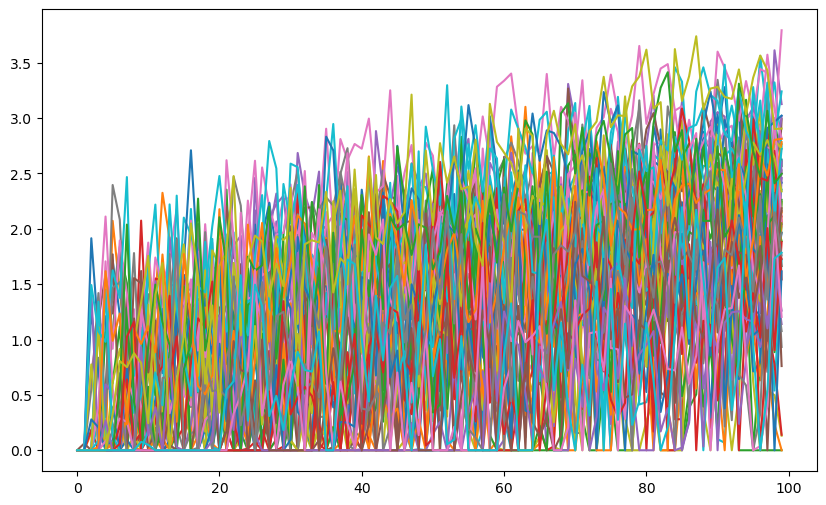

In [6]:
result_loc = 'data/Annual_GPR'
deficits = np.load(f'{result_loc}/test4_deficit_array.npy')
climate_classes = np.load(f'{result_loc}/test4_climate_classes.npy')
# plot the deficit for w=0
plt.figure(figsize=(10, 6))
for i in range(60):
    plt.plot(deficits[i], label=f'Climate {i}')

# print climate_classes
climate_indices = {}
# Iterate over the climate_classes array with index
for index, c_class in enumerate(climate_classes):
    if c_class in climate_indices:
        climate_indices[c_class].append(index)
    else:
        climate_indices[c_class] = [index]

#
# Print the indices with c_class from smallest to largest
for c_class in sorted(climate_indices):
    print(f"Climate Classification {c_class}: Indices {climate_indices[c_class]}")
#sum the number of climates in each classification
unique, counts = np.unique(climate_classes, return_counts=True)
climate_counts = dict(zip(unique, counts))
climate_counts


In [22]:
#note use!!!!!sample 20 climates from each classification
np.random.seed(28)
training = np.array([249, 312, 244, 512, 106, 522, 172, 107,  79,  26, 196,  27])
test_05 = np.random.choice(climate_indices[0.5], 20, replace=False)
test_10 = np.random.choice(climate_indices[1], 20, replace=False)
test_15 = np.random.choice(climate_indices[1.5], 20, replace=False)
test_20 = np.random.choice(climate_indices[2], 20, replace=False)
test_25 = np.random.choice(climate_indices[2.5], 20, replace=False)
test_30 = np.array([3, 73, 92, 98, 141, 146, 148, 165, 189])

print(test_05)
print(test_10)
print(test_15)
print(test_20)
print(test_25)
print(test_30)

# Check if there is any overlap between the test indices and training indices
overlap_05 = np.intersect1d(test_05, training)
overlap_10 = np.intersect1d(test_10, training)
overlap_15 = np.intersect1d(test_15, training)
overlap_20 = np.intersect1d(test_20, training)
overlap_25 = np.intersect1d(test_25, training)
overlap_30 = np.intersect1d(test_30, training)

if len(overlap_05) > 0:
    print("Overlap found in test_05 and training indices:", overlap_05)
if len(overlap_10) > 0:
    print("Overlap found in test_10 and training indices:", overlap_10)
if len(overlap_15) > 0:
    print("Overlap found in test_15 and training indices:", overlap_15)
if len(overlap_20) > 0:
    print("Overlap found in test_20 and training indices:", overlap_20)
if len(overlap_25) > 0:
    print("Overlap found in test_25 and training indices:", overlap_25)
if len(overlap_30) > 0:
    print("Overlap found in test_30 and training indices:", overlap_30)

[263 281 258 361 331 306 326 259 293 516 376 434 531 386 295 429 366 308
 275 337]
[264 447 499 212 261 311 291 566 288 294 466 304 526 571 457 390 318 359
 279 342]
[404 456 128 438 423 111 365 215 364  67 490 564 534 477 253  94 593 273
 348 595]
[ 66  38 464  46 174 439  56  71 408 151 415 190 100 118 112  85  89 453
  25 419]
[103  39  53  81  77 184  19 164 122  21  32 130 181   4 121 134 156   5
  50  11]
[  3  73  92  98 141 146 148 165 189]


In [ ]:
training = np.array([249, 312, 244, 512, 106, 522, 172, 107,  79,  26, 196,  27])

#select training cliamtes

In [13]:

def split_train_evaluate(climate_classes, n, seed=666):
    """
    Splits climate dataset into training and evaluation sets.

    Parameters:
    - climate_classes: Array of climate classifications.
    - n: Number of climates to sample from each classification for the training set.
    - seed: Random seed for reproducibility.

    Returns:
    - train_indices: Indices of the training set.
    - evaluate_indices: Indices of the evaluation set.
    """
    np.random.seed(seed)
    sampled_climates = []
    for i in np.unique(climate_classes):  
        if  i!=4:  # note 4 is unclassified, so don't select 
            sampled_climates.append(np.random.choice(np.where(climate_classes == i)[0], n, replace=False))
    sampled_climates = np.array(sampled_climates).flatten()

    # Create the train and evaluation indices
    train_indices = sampled_climates
    evaluate_indices = np.setdiff1d(np.arange(len(climate_classes)), train_indices)


    return train_indices, evaluate_indices

In [12]:
np.unique(climate_classes)

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 4. ])

In [16]:
train_indices, evaluate_indices = split_train_evaluate(climate_classes, 5,seed=961)
print("Train indices:", np.array(train_indices))
#print("Evaluate indices:", evaluate_indices)

Train indices: [548 376 380 565 230 354 428 547 207 245 443 554 109 570 504 467  73  50
 123  23 194   3 531 562 436  83 125 130  98  27]


In [8]:
training = np.array([548, 376, 380, 565, 230, 354, 428, 547, 207, 245, 443, 554, 109, 570, 504, 467, 73, 50,
                  123, 23, 194, 3, 531, 562, 436, 83, 125, 130, 98, 27])

test_d = [i for i in range(600) if i not in training and (climate_classes[i] == 2 or climate_classes[i] == 2.5)]
test_w = [i for i in range(600) if i not in training and  climate_classes[i] == 0]
test_v = [i for i in range(600) if i not in training and climate_classes[i] == 1 ]
test_all = np.concatenate([test_d, test_w, test_v])

In [15]:
len(test_all)

348

In [17]:
len(train_indices)

30

In [18]:

#print the corresponding cliamte classess
climate_classes[train_indices]

array([0. , 0. , 0. , 0. , 0. , 0.5, 0.5, 0.5, 0.5, 0.5, 1. , 1. , 1. ,
       1. , 1. , 1.5, 1.5, 1.5, 1.5, 1.5, 2. , 2. , 2. , 2. , 2. , 2.5,
       2.5, 2.5, 2.5, 2.5])

In [43]:
# set test set
test_all = [i for i in range(600) if i not in train_indices and climate_classes[i] != 4]
test_w = [i for i in range(600) if i not in train_indices and climate_classes[i] == 0.5]
test_v = [i for i in range(600) if i not in train_indices and climate_classes[i] == 1]
test_d = [i for i in range(600) if i not in train_indices and (climate_classes[i] == 2 or climate_classes[i] == 2.5)]

[2,
 3,
 5,
 6,
 7,
 8,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 37,
 38,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 50,
 51,
 53,
 54,
 55,
 56,
 57,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 70,
 71,
 72,
 73,
 74,
 75,
 78,
 79,
 80,
 81,
 83,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 139,
 140,
 141,
 142,
 145,
 146,
 147,
 148,
 150,
 151,
 152,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 162,
 163,
 165,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 175,
 176,
 177,
 178,
 180,
 181,
 182,
 183,
 184,
 185,
 187,
 188,
 189,
 190,
 191,
 192,
 193,
 194,
 195,
 196,
 197,
 198,
 199,
 200,
 202,
 204,
 205,
 207,
 209,
 212,
 213,
 214,
 215,
 220,
 222,
 22

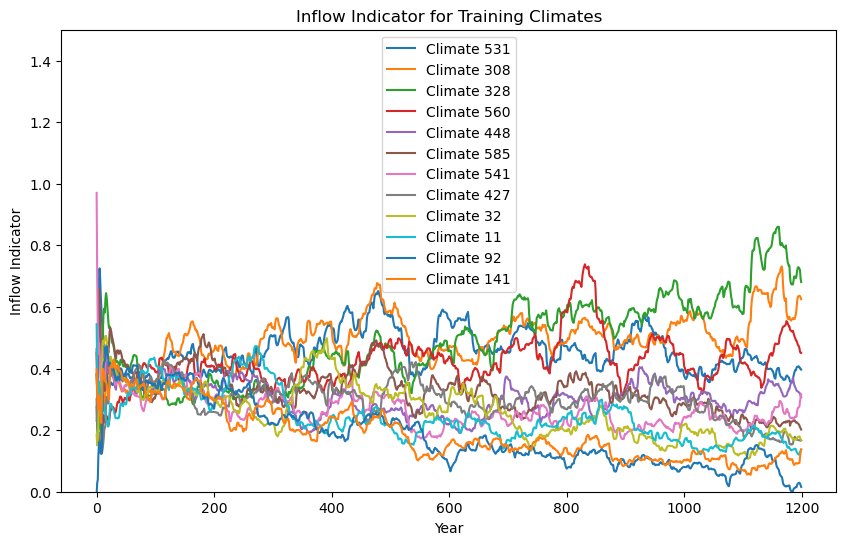

In [80]:
# plot corresponding inflow indicator
inflow_indicator = pd.read_csv('data/Annual_GPR/test3_inflow_indicators.csv')
plt.figure(figsize=(10, 6))
for i in train_indices:
    plt.plot(inflow_indicator.iloc[:, i], label=f'Climate {i}') 
plt.xlabel('Year')
plt.ylabel('Inflow Indicator')
plt.title('Inflow Indicator for Training Climates')
plt.ylim(0,1.5)
plt.legend()
plt.show()

# compute bayes indicators of training cliamtes

In [24]:
climate_means = np.load('data/Annual_GPR/test3_bayes_indicators.npz')['mu']
climate_sigmas = np.load('data/Annual_GPR/test3_bayes_indicators.npz')['std']

In [81]:
import utils_indicators as ut_indicators
# extract climate indicators
nsim = train_indices
num_models = len(nsim)
update_frequency = 2
H = 1200

mean_ts = np.zeros((H, num_models))
mean_t25s = np.zeros((H, num_models))
mean_t2100 = np.zeros((H, num_models))
std_t2100 = np.zeros((H, num_models))

for i, model_idx in enumerate(nsim):
    for t in range(H):
        # Extract indicators
        indicators = ut_indicators.extract_climate_indicators(climate_means[model_idx, ...], climate_sigmas[model_idx, ...], update_frequency, t)
        mean_ts[t, i] = indicators[0]
        mean_t25s[t, i] = indicators[1]
        mean_t2100[t, i] = indicators[2]
        std_t2100[t, i] = indicators[3]




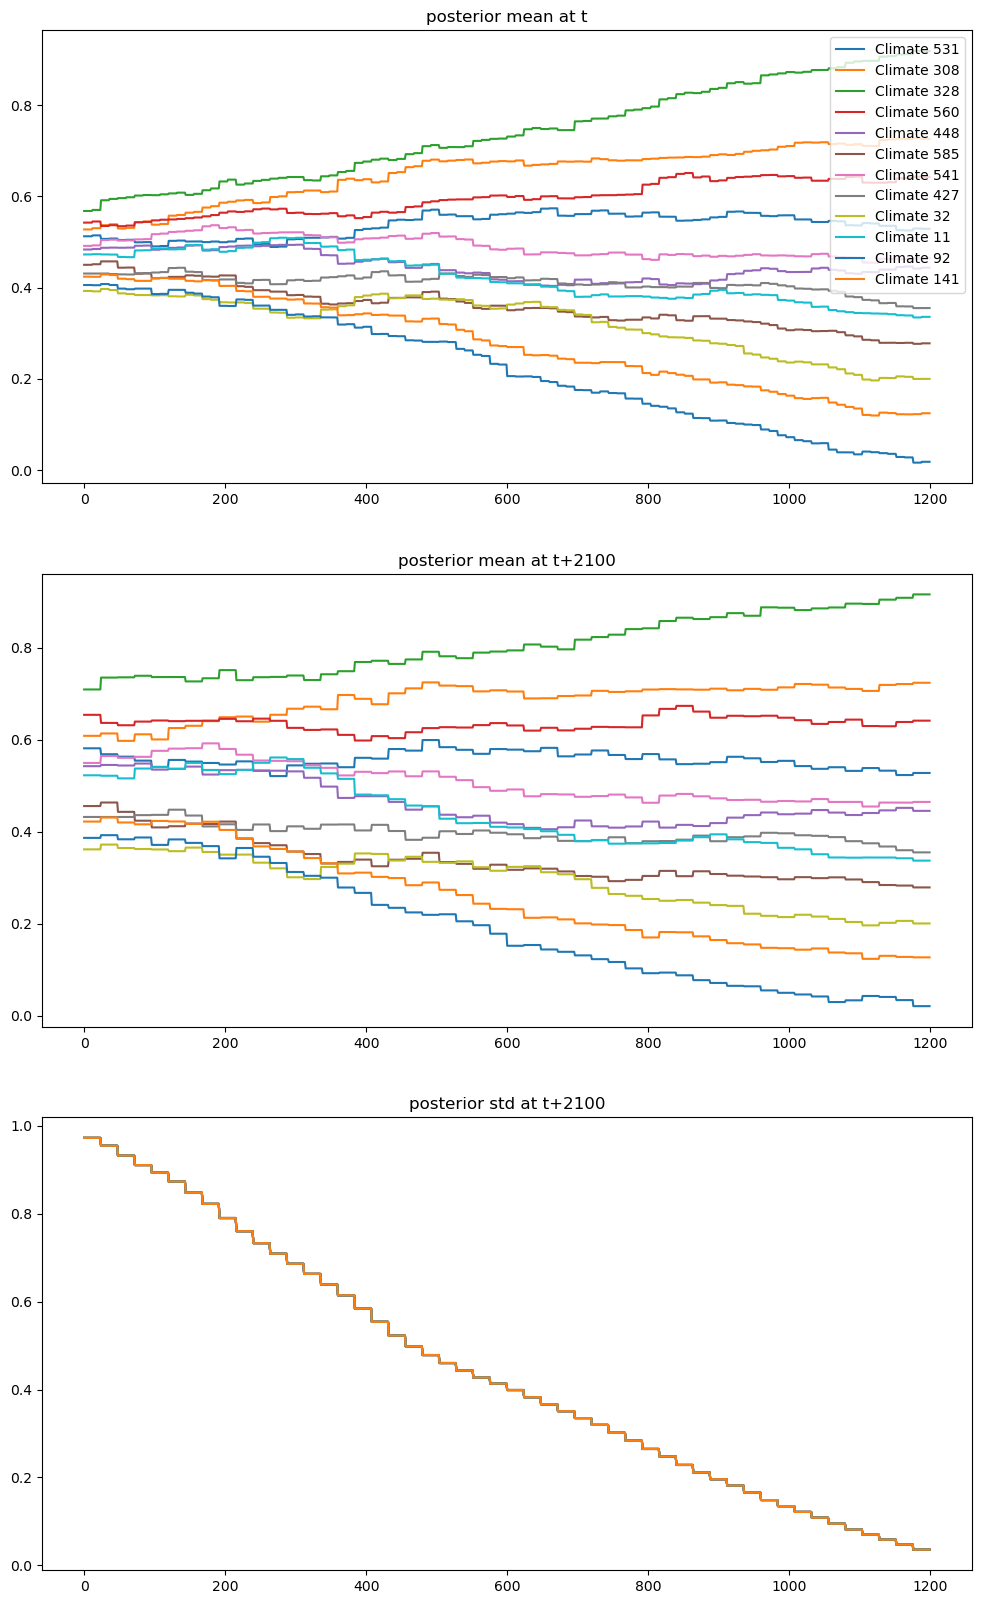

In [82]:
# plot cliamte indicators, as four (4*1) sub plots, add legend for each cliamte indices, and title for each sub plot
fig, axs = plt.subplots(3, 1, figsize=(12, 20))
for i in range(num_models):
    axs[0].plot(mean_ts[:, i], label=f'Climate {train_indices[i]}')
    axs[0].set_title('posterior mean at t')
    axs[1].plot(mean_t2100[:, i], label=f'Climate {train_indices[i]}')
    axs[1].set_title('posterior mean at t+2100')
    axs[2].plot(std_t2100[:, i], label=f'Climate {train_indices[i]}')
    axs[2].set_title('posterior std at t+2100')
axs[0].legend()
plt.show()





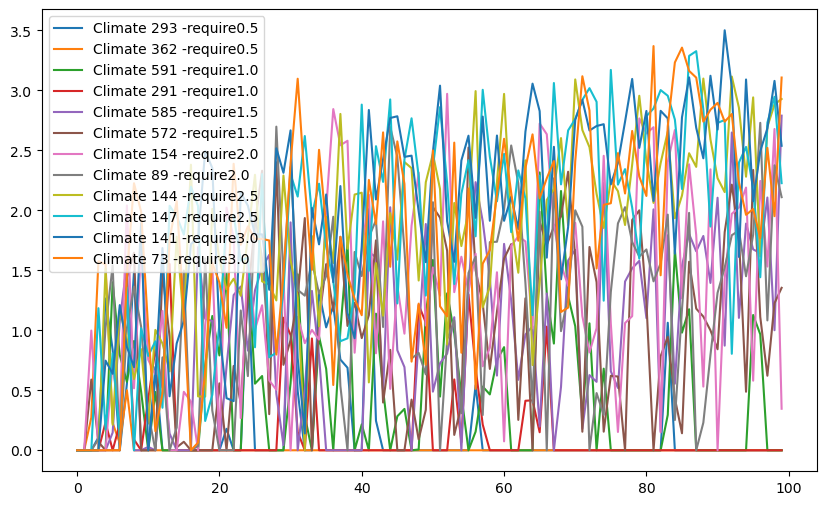

In [18]:
# plot deficit_array[train_indices]
plt.figure(figsize=(10, 6))
for i in train_indices:
    plt.plot(deficit_array[i], label=f'Climate {i} -require{climate_classes[i]}')
plt.legend()



#train under 20 (sample 4 for each)


In [82]:
np.array([326, 337, 383, 236, 458, 201, 209, 231, 535,  40, 378, 567, 108,
       163, 492, 117,  39,  25,  42,  21])



array([326, 337, 383, 236, 458, 201, 209, 231, 535,  40, 378, 567, 108,
       163, 492, 117,  39,  25,  42,  21])

In [74]:
np.array([326, 337, 383, 236, 390, 259, 312, 211, 382, 270, 458, 201, 209,
       231, 459, 287, 392, 344, 255, 368, 535,  40, 378, 567, 408, 239,
       524, 290, 393, 573, 108, 163, 492, 117, 513, 176, 198, 403, 569,
       167,  39,  25,  42,  21, 119, 123, 103,  24, 148,  14])

array([326, 337, 383, 236, 390, 259, 312, 211, 382, 270, 458, 201, 209,
       231, 459, 287, 392, 344, 255, 368, 535,  40, 378, 567, 408, 239,
       524, 290, 393, 573, 108, 163, 492, 117, 513, 176, 198, 403, 569,
       167,  39,  25,  42,  21, 119, 123, 103,  24, 148,  14])

In [77]:
installed_capacity = [1,1,1,1,1,1,2,2,2,3,3]
operate = 0.5
np.sum(operate * np.array(installed_capacity))

9.0

In [62]:
np.random.choice(np.where(climate_classes == 3)[0], 10, replace=False)

array([ 83, 104, 547, 527, 529, 137, 140, 144, 136, 585])

In [65]:
# sample 10 random climates from each classification
# save the sample climate index
np.random.seed(666)
sampled_climates = []
for i in range(5):
    sampled_climates.append(np.random.choice(np.where(climate_classes == i)[0], 10, replace=False))
sampled_climates = np.array(sampled_climates)

print(sampled_climates)




[[326 337 383 236 390 259 312 211 382 270]
 [458 201 209 231 459 287 392 344 255 368]
 [535  40 378 567 408 239 524 290 393 573]
 [108 163 492 117 513 176 198 403 569 167]
 [ 39  25  42  21 119 123 103  24 148  14]]


In [5]:
require_0 = np.array([20, 21, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 46, 48, 52, 53, 56])
require_1 = np.array([6, 12, 13, 15, 16, 29, 30, 40, 41, 43, 44, 45, 47, 50, 51, 54, 55, 57, 58, 59])
require_2 = np.array([0, 1, 2, 3, 4, 5, 7, 8, 10, 11, 14, 17, 18, 19, 42, 49])

28
40
116
124
139
160
162
200
201
202
204
205
207
209
211
212
214
216
218
221
222
223
224
225
226
228
229
230
231
233
234
236
237
240
241
243
244
245
246
247
248
249
251
252
254
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
275
276
279
280
281
282
283
284
288
289
290
291
293
294
295
296
297
299
300
301
303
304
306
307
308
309
310
311
312
314
315
316
318
319
320
323
324
325
326
327
328
330
331
333
335
337
338
339
340
342
345
350
351
352
356
357
358
359
360
361
362
363
366
367
368
369
370
371
372
373
374
375
376
377
378
379
380
382
384
385
386
388
390
391
392
393
395
397
398
399
402
407
409
416
422
425
428
429
430
433
434
436
440
449
451
457
458
459
460
463
465
466
468
470
472
475
491
493
494
495
497
499
500
506
508
511
512
514
516
524
526
531
533
535
537
538
539
540
551
552
560
562
563
566
568
571
575
576
580
586
588
592
213


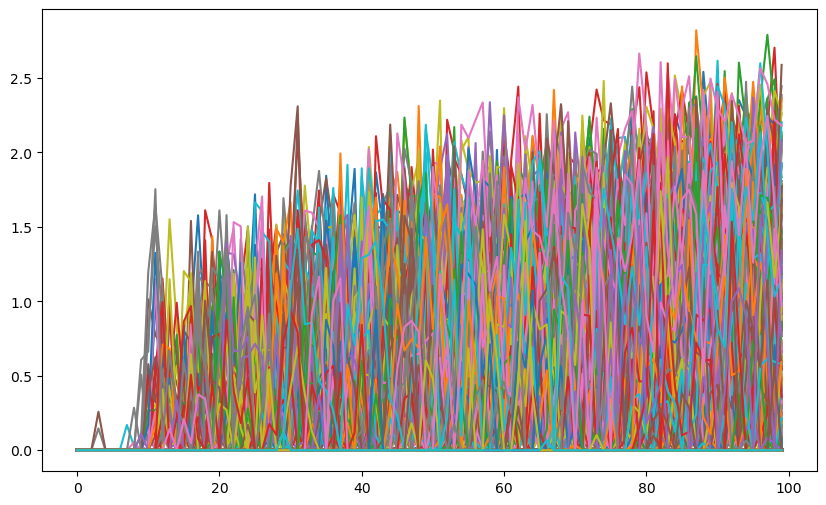

In [30]:
H = 1200
demand = np.ones(H) * 5.5
hedge_param = 15
smax = 60
initial_storage  = 45
#nsim = np.concatenate([np.arange(0, 3), np.arange(20, 23), np.array([40,41,43])])
nsim = np.arange(0,600)

# Create a simulation object
res_simulation = ReservoirSimulation(hedge_param, smax)

# Initialize plot
plt.figure(figsize=(10, 6))
count = 0
deficit_list = []
# Loop over inflow scenarios
for i in nsim:
    inflow = inflows.iloc[:, i].values 

    # Initialize arrays
    s_next = np.zeros(H + 1)  # storage
    s_next[0] = initial_storage
    r = np.zeros(H)
    deficit = np.zeros(H)
    balance = np.zeros(H)

    # Run the simulation
    for t in range(H):
        w = 1
        demand_ = demand[t] - w
        s_next[t + 1], r[t], deficit[t], balance[t] = res_simulation.operate(s_next[t], demand_, inflow[t])

    # Calculate mean annual deficit
    mean_annual_deficit = np.mean(deficit.reshape(-1, 12), axis=1)

    # appen mean annual defict of current climate to the deficit_list
    deficit_list.append(mean_annual_deficit)

    # Plot mean annual deficit
    plt.plot(mean_annual_deficit, label = f'climate{i}')
    if (np.sum(mean_annual_deficit[5:])==0):
        count+=1
        print(i)

    #else:
        #print(np.sum(mean_annual_deficit[5:]),i)

# Convert deficit_list to a numpy array for further processing if needed
deficit_array = np.array(deficit_list)
deficit_array.shape


print(count)
# Plot formatting
#plt.title('Mean Annual Deficit for Different Inflow Scenarios')
#plt.xlabel('Year')
#plt.ylabel('Mean Annual Deficit [MCM]')
#plt.legend()
#plt.grid(True)
#plt.show()



Text(0.5, 1.0, 'Annual Inflow for Different Inflow Scenarios')

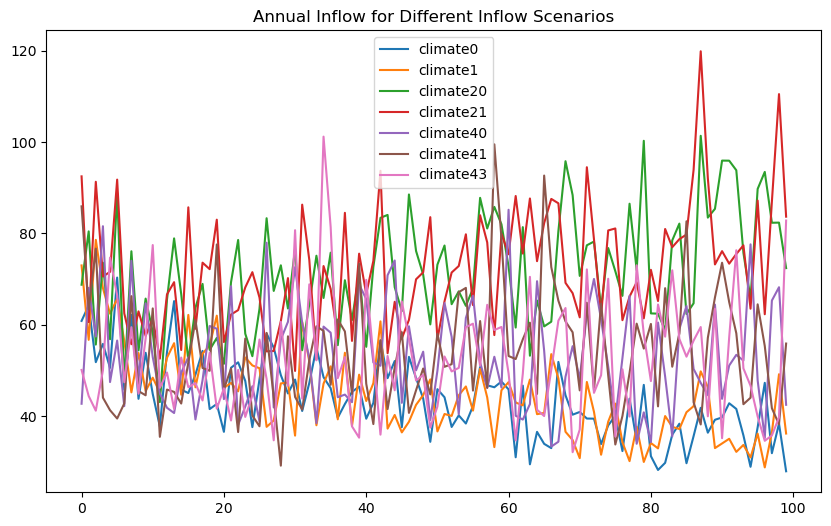

In [11]:
plt.figure(figsize=(10, 6))
nsim = np.concatenate([np.arange(0, 2), np.arange(20, 22), np.array([40,41,43])]) 
#nsim = np.concatenate([np.arange(0, 3), np.arange(20, 23), np.array([40,41,43])])
#nsim = require_2
for i in nsim:
    inflow = inflows.iloc[:, i].values
    annual_inflow = np.sum(inflow.reshape(-1, 12), axis=1)
    plt.plot(annual_inflow, label = f'climate{i}')
plt.legend()
plt.title('Annual Inflow for Different Inflow Scenarios')


Text(0.5, 1.0, 'Annual Precipitation for Different Inflow Scenarios')

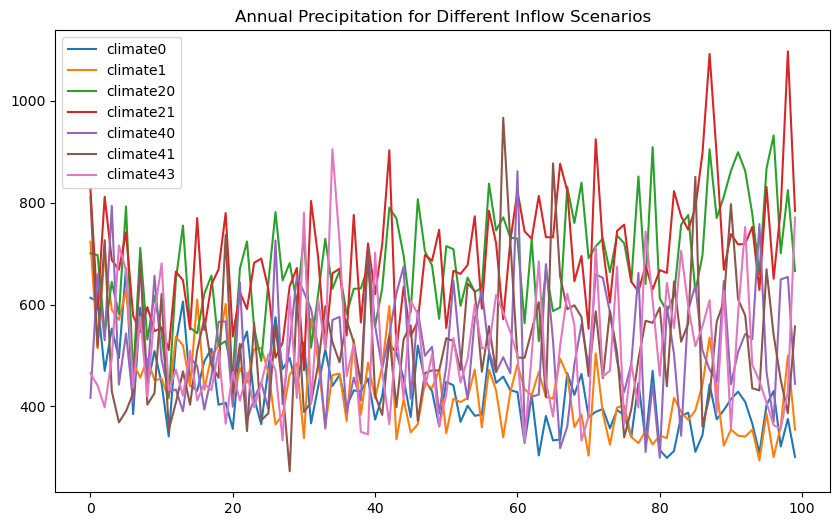

In [12]:
plt.figure(figsize=(10, 6))
nsim = np.concatenate([np.arange(0, 2), np.arange(20, 22), np.array([40,41,43])]) 
prep_mon = pd.read_csv('/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/Bayesian DPS optimization/data/Annual_GPR/test_month_prep.csv')
for i in nsim:
    prep = prep_mon.iloc[:, i].values
    annual_prep = np.sum(prep.reshape(-1, 12), axis=1)
    plt.plot(annual_prep, label = f'climate{i}')
plt.legend()
plt.title('Annual Precipitation for Different Inflow Scenarios')

#visuals of indicators and timing of capacity installed! 

Text(0.5, 0, 'Months')

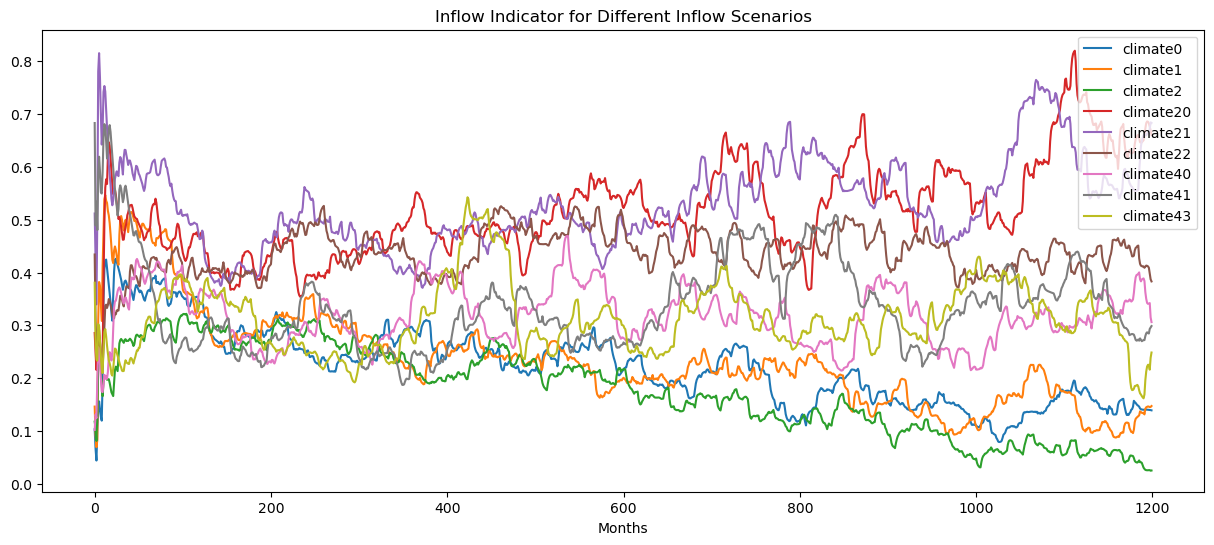

In [6]:
plt.figure(figsize=(15, 6))
#nsim = np.concatenate([np.arange(0, 2), np.arange(20, 22), np.array([40,41,43])])
nsim = np.concatenate([np.arange(0, 3), np.arange(20, 23), np.array([40,41,43])])

for i in nsim:
    inflow_indicator = inflow_indicators.iloc[:, i].values
    plt.plot(inflow_indicator, label = f'climate{i}')
plt.legend()
plt.title('Inflow Indicator for Different Inflow Scenarios')

plt.xlabel('Months')

In [5]:
num_models = 60
H = 100 * 12 # Number of years for which data is generated

# Pre-allocate numpy arrays for each set of indicators
mean_ts = np.zeros((H, num_models))
mean_t50s = np.zeros((H, num_models))
std_t50s = np.zeros((H, num_models))
mean_t2100 = np.zeros((H, num_models))
std_t2100 = np.zeros((H, num_models))
diff = np.zeros((H, num_models))


for model_idx in range(num_models):
    for t in range(H):
        
        # Extract indicators
        indicators = extract_climate_indicators(climate_means[model_idx,...], climate_stds[model_idx,...], 2, t)
        mean_ts[t, model_idx] = indicators[0]
        mean_t50s[t, model_idx] = indicators[1]
        std_t50s[t, model_idx] = indicators[2]
        mean_t2100[t, model_idx] = indicators[3]
        std_t2100[t, model_idx] = indicators[4]  
        diff[t, model_idx] = indicators[5]



In [6]:
mean_ts.shape

(1200, 60)

In [13]:
def plot_climate_indicators(inflows,inflow_indicators, mean_ts, mean_t50s, mean_t2100, std_t2100,  idx):


    years = np.arange(0, 1200) 

    fig, axs = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

    # inflow
    #axs[0].plot(years, inflows.iloc[:, idx].values, 'r-.', markersize=10, label='Noisy Inflow Observations')
    axs[0].plot(years, inflow_indicators.iloc[:, idx], label = "5-year smooth inflow at time t", color = 'black')
    axs[0].legend()
    axs[0].set_ylabel('inflow')

    # Mean at and std time t 
  
    axs[1].plot(years, mean_ts[:, idx], label='Mean at Time t', color='blue')
    #axs[1].fill_between(years, mean_ts[:, idx] - 6*std_ts[:, idx], mean_ts[:, idx] + 6*std_ts[:, idx], color='blue', alpha=0.2, label='+- 1 std')
    axs[1].plot(years, mean_t2100[:, idx], label='Mean at 2100', color='green')
    #axs[1].fill_between(years, mean_t2100[:, idx] - std_t2100[:, idx], mean_t2100[:, idx] + std_t2100[:, idx], color='green', alpha=0.2, label='+- 1 std')
    axs[1].set_ylabel('posterior mean and uncertainty at t')
    axs[1].legend()

    # Mean at and std year 2100 

    axs[2].plot(years, mean_t2100[:, idx], label='Mean at 2100', color='green')
    axs[2].fill_between(years, mean_t2100[:, idx] - std_t2100[:, idx], mean_t2100[:, idx] + std_t2100[:, idx], color='green', alpha=0.2, label='+- 1 std')

    axs[2].set_ylabel('Posterior mean and uncertainty  at year2100')
    axs[2].set_xlabel('Year')
    axs[2].legend()



    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for figure title
    plt.show()

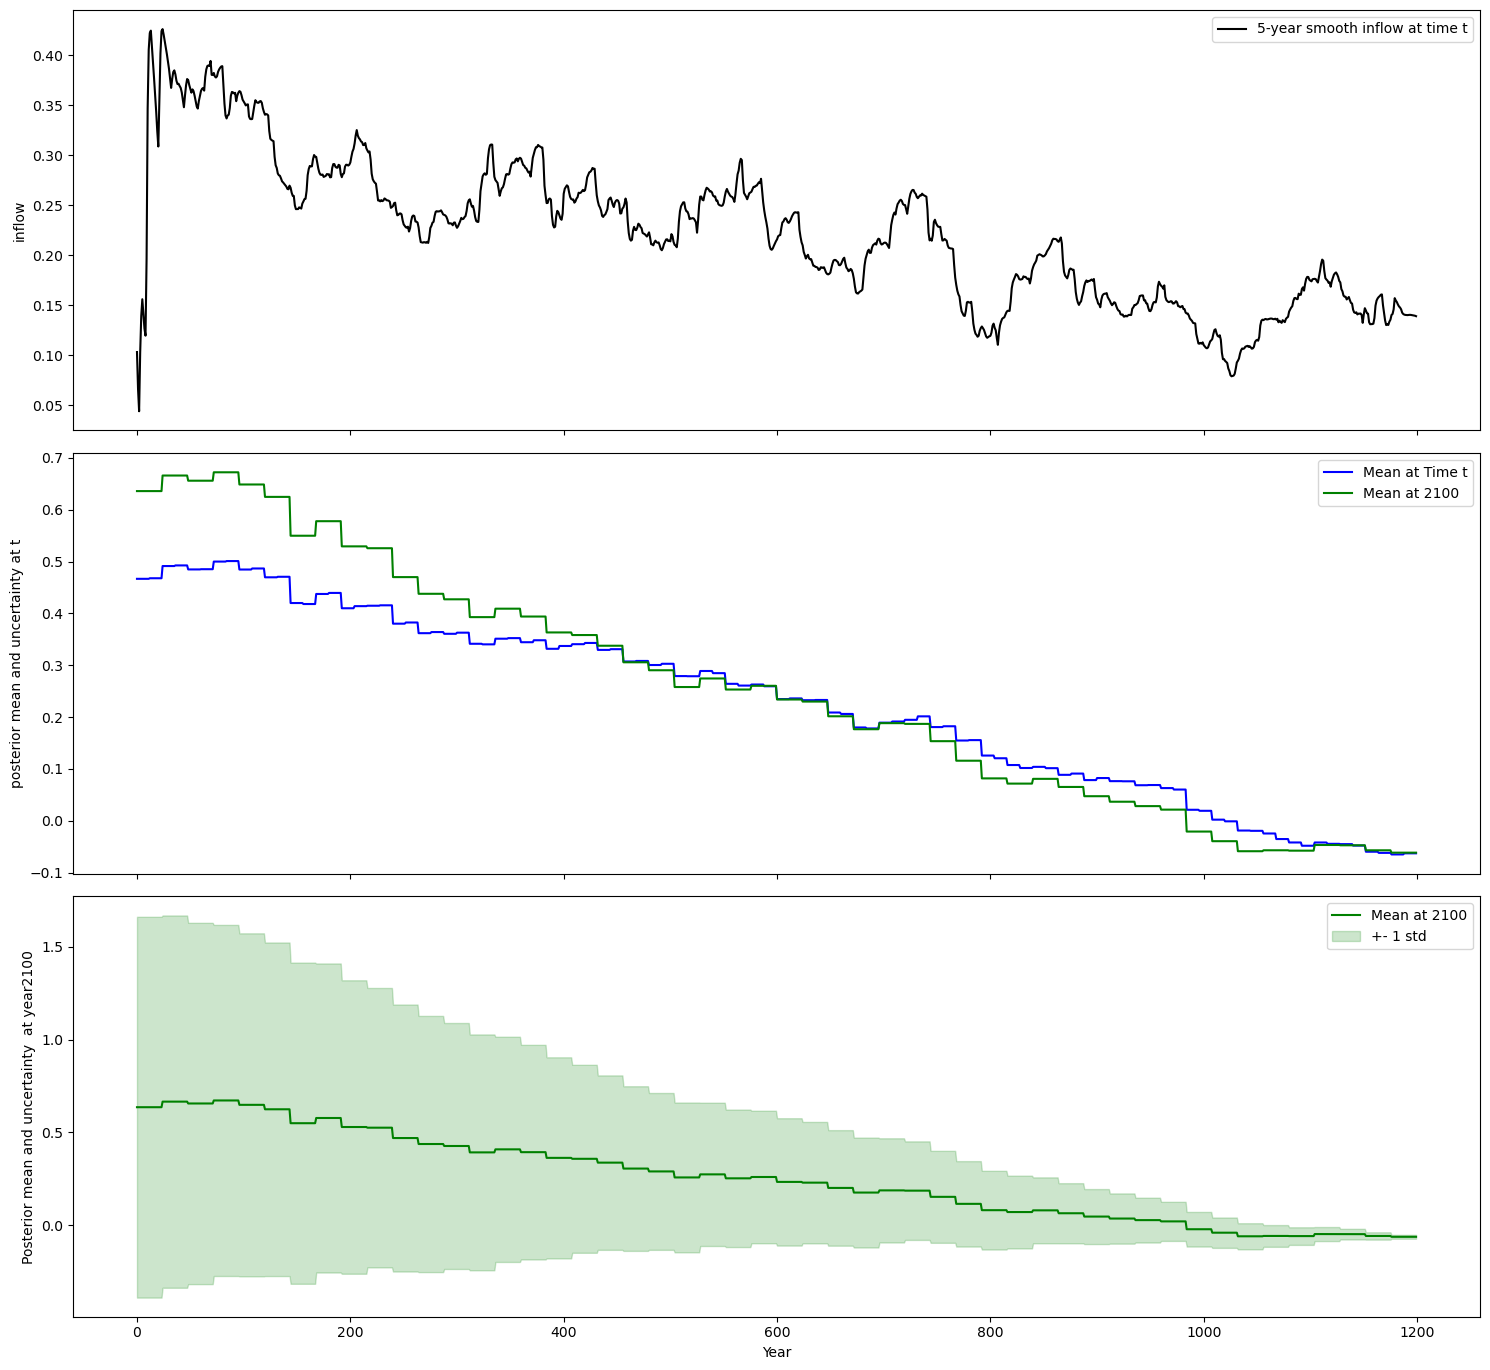

In [60]:
idx = 0
plot_climate_indicators(inflows, inflow_indicators ,mean_ts, mean_t50s, mean_t2100, std_t2100, idx)

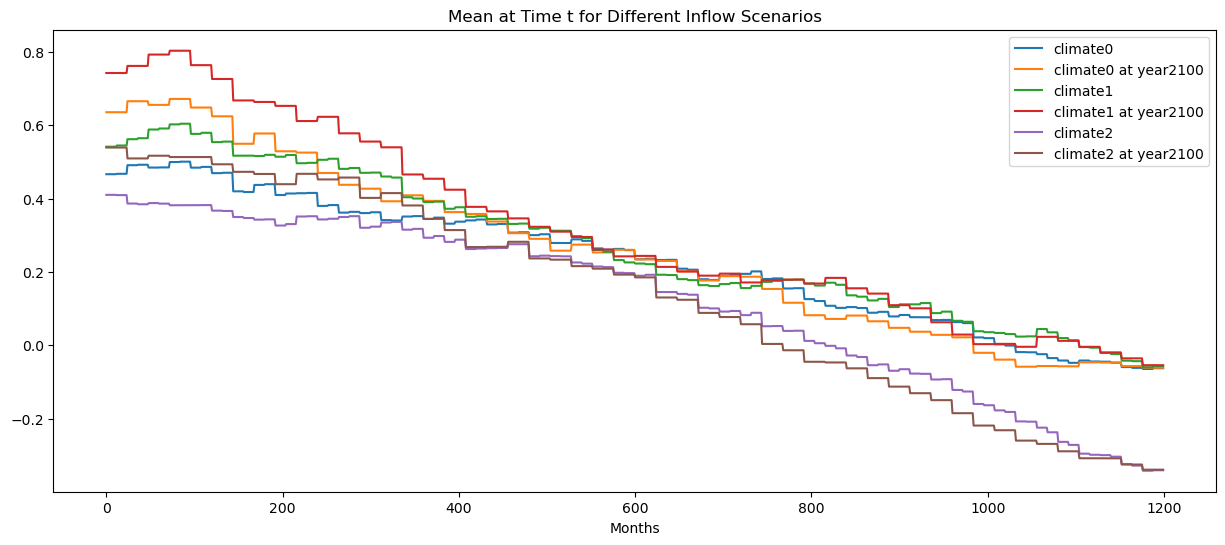

In [7]:

plt.figure(figsize=(15, 6))
#nsim = np.concatenate([np.arange(0, 2), np.arange(20, 22), np.array([40,41,43])])
#nsim = np.concatenate([np.arange(0, 3), np.arange(20, 23), np.array([40,41,43])])
nsim = np.concatenate([np.arange(0,3)])

for i in nsim:
    mean_t = mean_ts[:, i]
    plt.plot(mean_t, label = f'climate{i}')
    plt.plot(mean_t2100[:, i], label = f'climate{i} at year2100')
plt.title('Mean at Time t for Different Inflow Scenarios')
plt.xlabel('Months')
plt.legend()

0
1
2
20
21
22
40
41
43


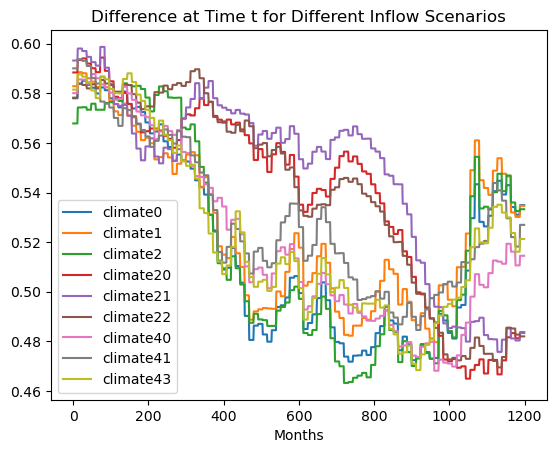

In [10]:
for i in nsim:
    print(i)
    diff_i = diff[:,i]
    plt.plot(diff_i, label = f'climate{i}')
plt.title('Difference at Time t for Different Inflow Scenarios')
plt.xlabel('Months')
plt.legend()

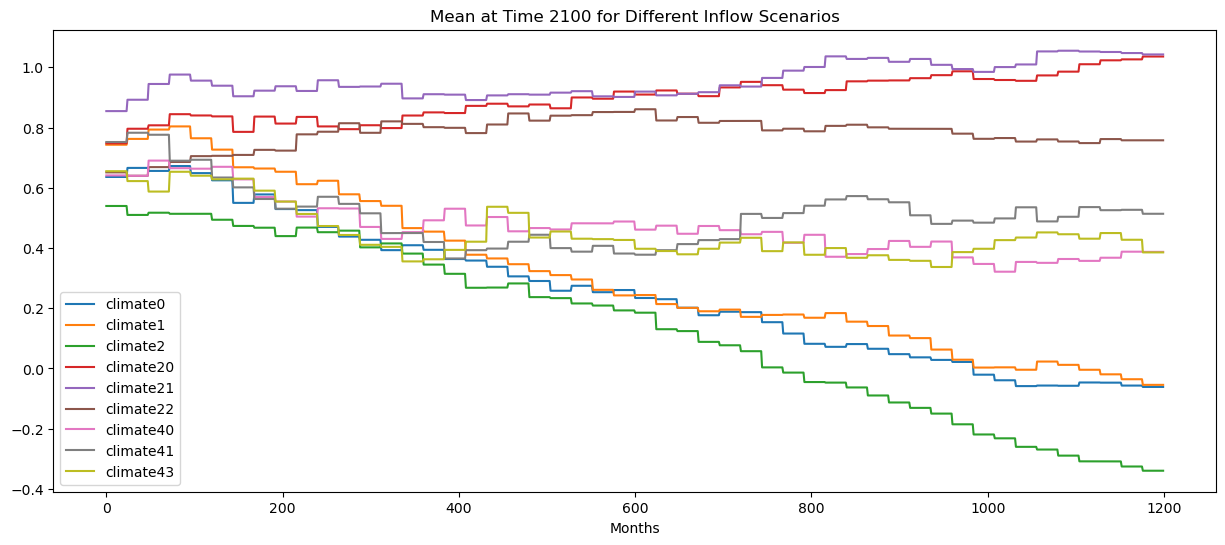

In [92]:
plt.figure(figsize=(15, 6))
#nsim = np.concatenate([np.arange(0, 2), np.arange(20, 22), np.array([40,41,43])])
nsim = np.concatenate([np.arange(0, 3), np.arange(20, 23), np.array([40,41,43])])


for i in nsim:
    mean_t = mean_t2100[:, i]
    plt.plot(mean_t, label = f'climate{i}')
plt.title('Mean at Time 2100 for Different Inflow Scenarios')
plt.xlabel('Months')
plt.legend()


In [ ]:
plt.figure(figsize=(10, 6))
nsim = np.concatenate([np.arange(0, 2), np.arange(20, 22), np.arange(40,42)]) 
for i in nsim:
    mean_t = mean_t2100[:, i]
    plt.plot(mean_t)
plt.title('Mean at Time 2100 for Different Inflow Scenarios')

Text(0.5, 1.0, 'std at Time 2100 for Different Inflow Scenarios')

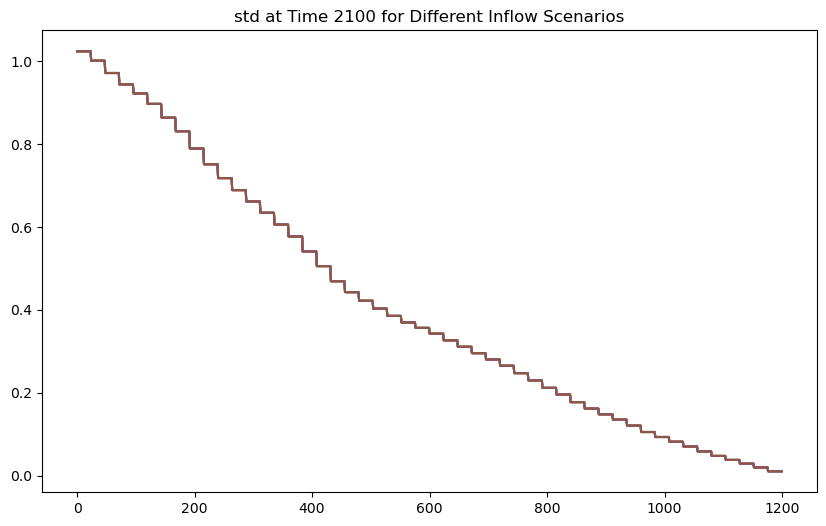

In [14]:
plt.figure(figsize=(10, 6))
nsim = np.concatenate([np.arange(0, 2), np.arange(20, 22), np.arange(40,42)]) 
for i in nsim:
    std_t = std_t2100[:, i]
    plt.plot(std_t)
plt.title('std at Time 2100 for Different Inflow Scenarios')

0604 Experiments: plot the timing of capacity installed or expanded 

In [36]:
#read in timing
# Read Bayes timing data from JSON
with open('data/Annual_GPR/bayes_timing_data.json', 'r') as json_file:
    bayes_timing= json.load(json_file)

# Read Norm timing data from JSON
with open('data/Annual_GPR/norm_timing_data.json', 'r') as json_file:
    norm_timing = json.load(json_file)

In [44]:

def plot_bayes_indicators_with_timing(indicators, bayes_timing, nsim, bayes = True):
    """
    Plot Bayes indicators time series with overlay of timing data.

    Parameters:
    - indicators: Array of shape (n_timesteps, n_climates) containing the Bayes indicators time series.
    - bayes_timing: List of lists containing the timing of capacity installed or expanded for each climate.
    - nsim: List of indices specifying the climates to plot.
    """

    plt.rcParams.update({'font.size': 14})  # Enlarge all font sizes
    n_timesteps = indicators.shape[0]
    fig, ax = plt.subplots(figsize=(15, 10))

    colors = plt.cm.viridis(np.linspace(0, 1, len(nsim)))

    for idx, climate in enumerate(nsim):
        timing = bayes_timing[climate]
        if bayes:
            ax.plot(np.arange(n_timesteps), indicators[:, climate], label=f'Climate {climate}', color=colors[idx],linewidth=2)
        else:
            ax.plot(np.arange(n_timesteps), indicators[:, climate], label=f'Climate {climate}', color=colors[idx],linestyle='--')
        # Overlay timing data
        for t in timing:
            ax.plot(t, indicators[t, climate], 'o', markersize = 12,color=colors[idx]) 
    
    if bayes:

        ax.set_title('Bayes Indicators with Timing Overlaid')
        ax.set_ylabel('Bayes Indicator')
    else:
        ax.set_title('Norm Indicators with Timing Overlaid')
        ax.set_ylabel('Norm Indicator')
    ax.set_xlabel('Time Step')
    ax.legend()
    plt.tight_layout()
    plt.show()

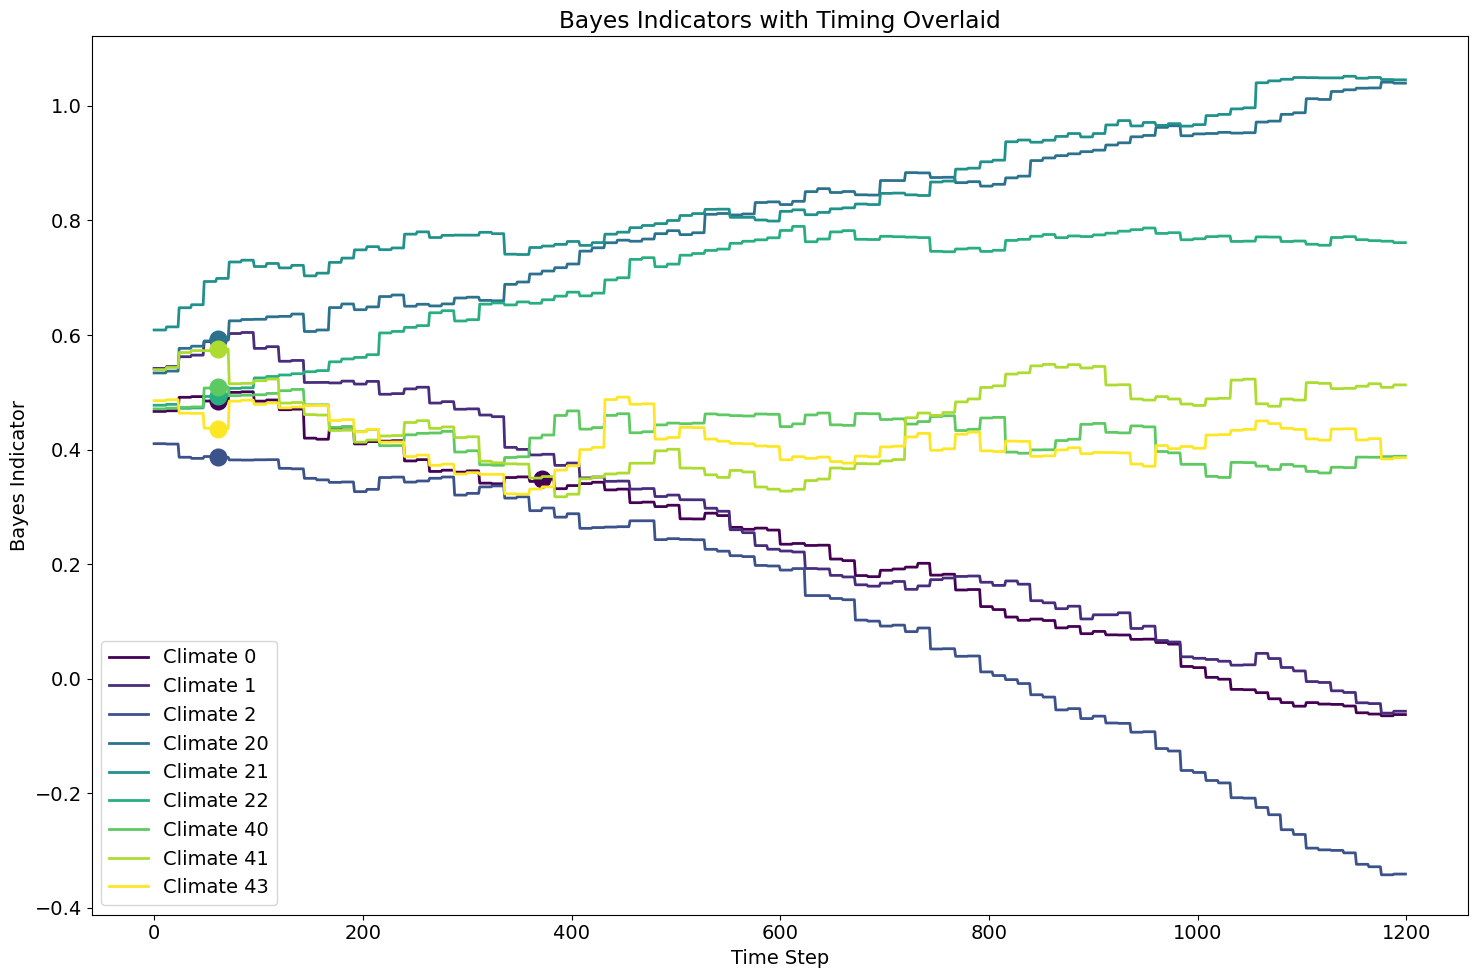

In [45]:
plot_bayes_indicators_with_timing(mean_ts, bayes_timing, nsim, True)

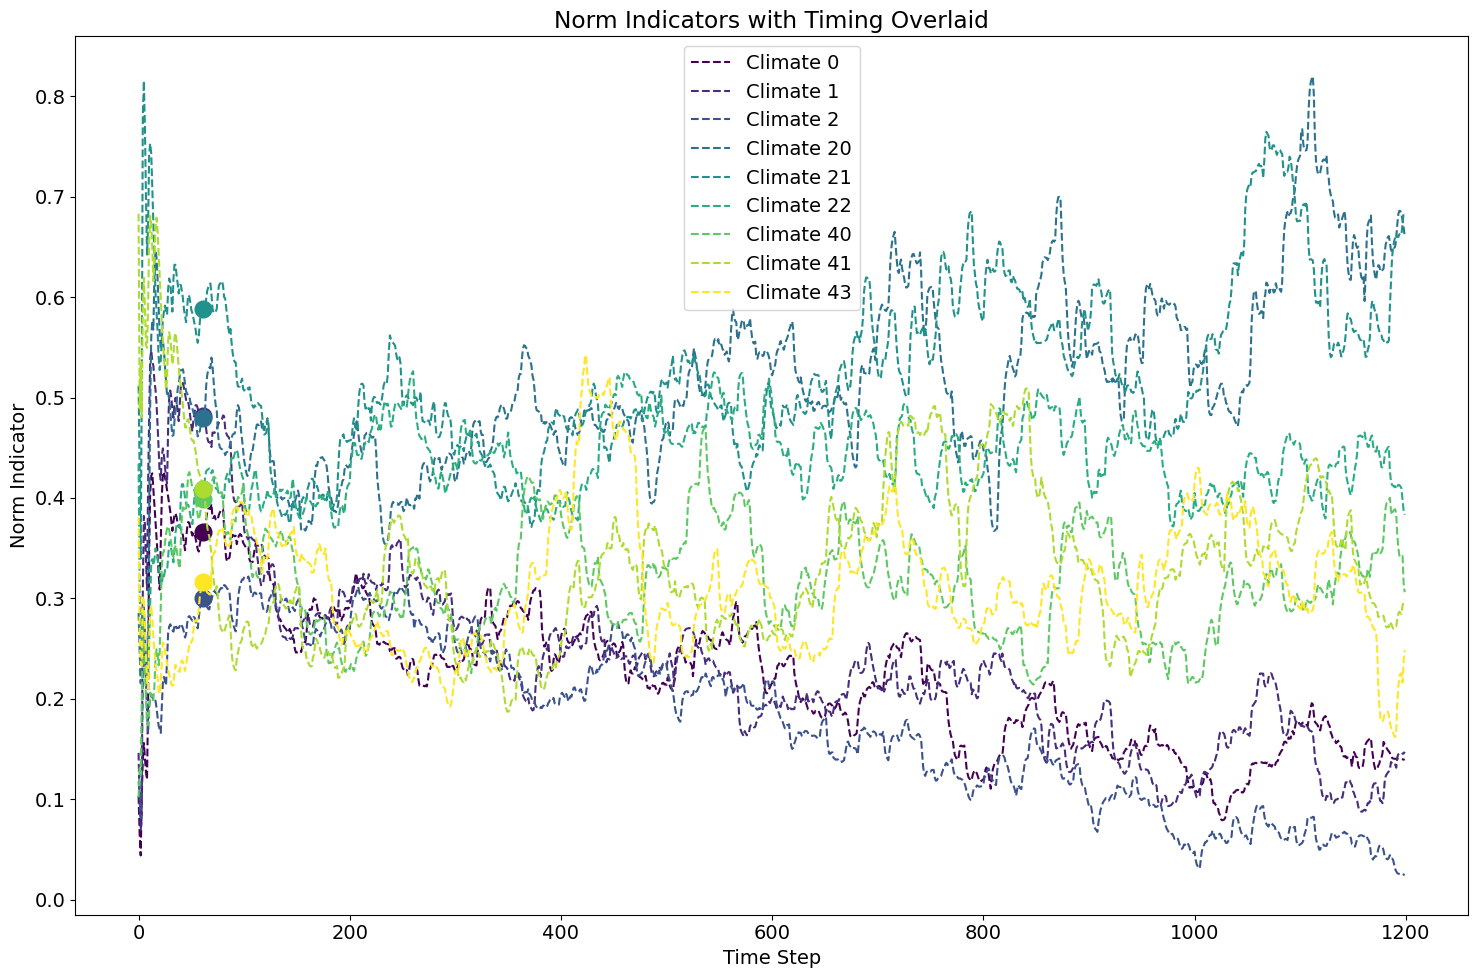

In [46]:
plot_bayes_indicators_with_timing(np.array(inflow_indicators), norm_timing, nsim, False)

2024.5.30  Experiment1: Bayesian indicator is a more useful indicator than inflow indicato
Make scatter plot: indicators vs cumulative deficit

1. bayes indicators are more predictive of future cumulative deficit 
scatter plot
x axis: indicators at first deficit time (t = 61)
y axis: cumulative deficit at year 10, 50, 100

In [54]:
for climate in range(60):
    if climate not in require_0 and climate not in require_1 and climate not in require_2:
        print(climate)

9


In [80]:
def  predict_scatter(deficit_array, mean_ts, inflow_indicators, require_0, require_1, require_2, time_horizons=[5, 10, 15]):
    """
    Generate scatter plots to compare the correlation between indicators and cumulative deficits.

    Parameters:
    - deficit_array: Array of shape (n_climates, n_years) containing the mean annual deficits.
    - mean_ts: Array of shape (n_timesteps, n_climates) containing the mean_ts indicators.
    - inflow_indicators:Dataframe of shape (n_timesteps, n_climates) containing the inflow indicators.
    - require_0: Array of indices specifying the climates that require 0 capacity.
    - require_1: Array of indices specifying the climates that require 1 capacity.
    - require_2: Array of indices specifying the climates that require 2 capacity.
    - time_horizons: List of time horizons in years for which to calculate cumulative deficits. 
    """
    n_climates = deficit_array.shape[0]
    markers = {0: 'o', 1: 's', 2: '^'}  # Different markers for each requirement


    fig, axes = plt.subplots(1, len(time_horizons), figsize=(18, 6))

    for idx, horizon in enumerate(time_horizons):
    
        if horizon >= deficit_array.shape[1] :
            print(f"Time horizon {horizon} years exceeds the data range. Skipping.")
            continue

        cumulative_deficits = np.sum(deficit_array[:, horizon:], axis=1)
       
        time_step = horizon*12 
        bayes_indicator = mean_ts[time_step, :]
        inflow_indicator = inflow_indicators.iloc[time_step, :]

        for climate in range(n_climates):
            if climate in require_0:
                marker = markers[0]
                label = 'Require 0 Capacity'
            elif climate in require_1:
                marker = markers[1]
                label = 'Require 1 Capacity'
            elif climate in require_2:
                marker = markers[2]
                label = 'Require 2 Capacity'
            else:
                marker = 'x'
                label = 'other'

            axes[idx].scatter(bayes_indicator[climate], cumulative_deficits[climate], c='blue', marker=marker, label='Mean_ts Indicator' if climate == require_0[0] else "")
            axes[idx].scatter(inflow_indicator[climate], cumulative_deficits[climate], c='red', marker=marker, alpha=0.5, label='Inflow Indicator' if climate == require_0[0] else "")

            # Plot shape markers
            if climate == require_0[0]:
                axes[idx].scatter([], [], c='black', marker=markers[0], label='Require 0 Capacity')
            elif climate == require_1[0]:
                axes[idx].scatter([], [], c='black', marker=markers[1], label='Require 1 Capacity')
            elif climate == require_2[0]:
                axes[idx].scatter([], [], c='black', marker=markers[2], label='Require 2 Capacity')

        axes[idx].set_xlabel(f'Indicator at t= year{horizon}')
        axes[idx].set_ylabel(f'Cumulative Deficit (Year {horizon})')
        axes[idx].set_title(f'Correlation: Indicator at year {horizon} vs. Cumulative Deficit from Year {horizon}) ')
    
    # Add legends only once for each plot
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right')

    plt.tight_layout()
    plt.show()




/var/folders/hb/_43wlmv965x3b24_f7phntnr0000gn/T/ipykernel_2983/1322220479.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[idx].scatter(inflow_indicator[climate], cumulative_deficits[climate], c='red', marker=marker, alpha=0.5, label='Inflow Indicator' if climate == require_0[0] else "")


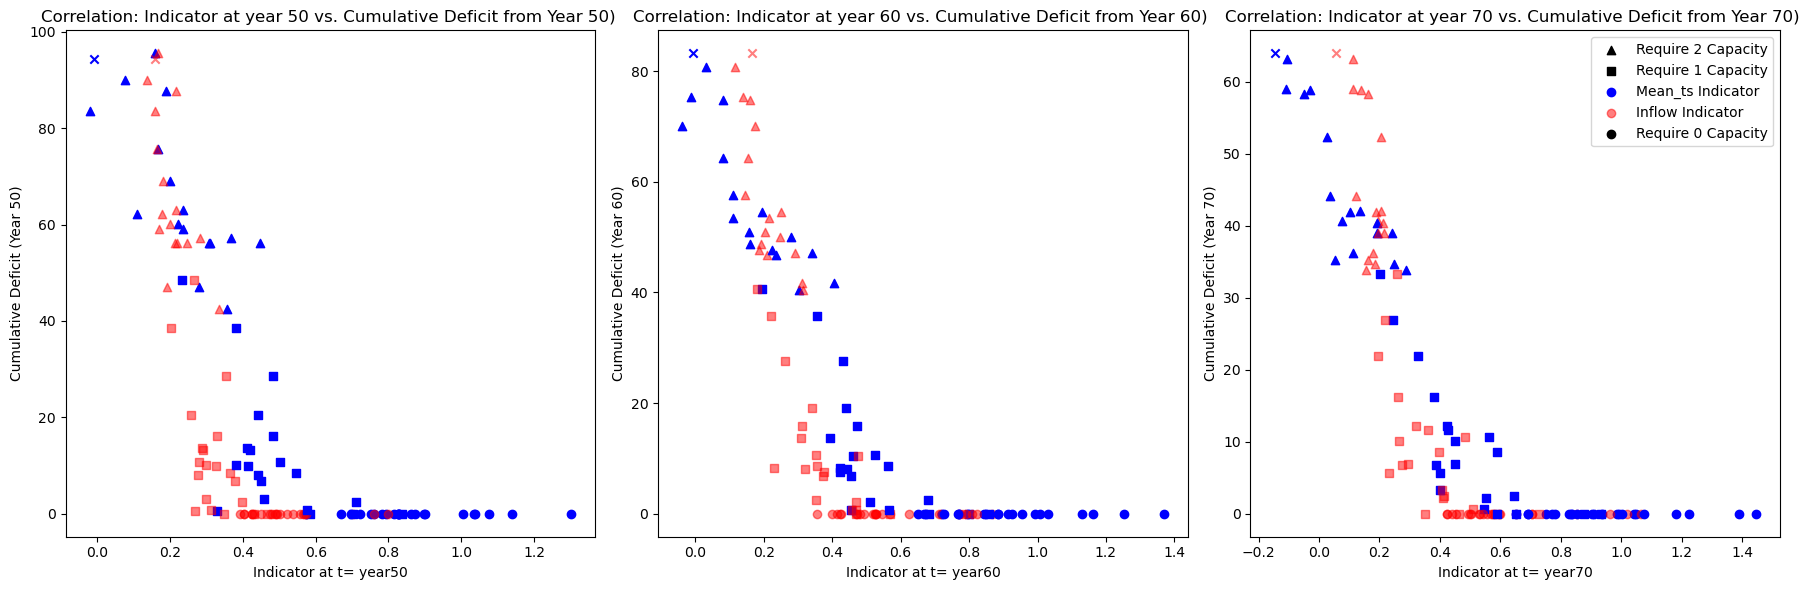

In [83]:
predict_scatter(deficit_array, mean_ts, inflow_indicators,require_0, require_1, require_2, time_horizons=[50, 60, 70])

1. bayes indicators are more correlated of future cumulative deficit 
scatter plot
x axis: indicators at year 10, 50, 100
y axis: cumulative deficit at year 10, 50, 100

In [58]:
def  cor_scatter(deficit_array, mean_ts, inflow_indicators, require_0, require_1, require_2, time_horizons=[29, 49, 99]):
    """
    Generate scatter plots to compare the correlation between indicators and cumulative deficits.

    Parameters:
    - deficit_array: Array of shape (n_climates, n_years) containing the mean annual deficits.
    - mean_ts: Array of shape (n_timesteps, n_climates) containing the mean_ts indicators.
    - inflow_indicators:Dataframe of shape (n_timesteps, n_climates) containing the inflow indicators.
    - require_0: Array of indices specifying the climates that require 0 capacity.
    - require_1: Array of indices specifying the climates that require 1 capacity.
    - require_2: Array of indices specifying the climates that require 2 capacity.
    - time_horizons: List of time horizons in years for which to calculate cumulative deficits.
    """
    n_climates = deficit_array.shape[0]
    markers = {0: 'o', 1: 's', 2: '^'}  # Different markers for each requirement


    fig, axes = plt.subplots(1, len(time_horizons), figsize=(18, 6))

    for idx, horizon in enumerate(time_horizons):
    
        if horizon >= deficit_array.shape[1] :
            print(f"Time horizon {horizon} years exceeds the data range. Skipping.")
            continue
        
        cumulative_deficits = np.sum(deficit_array[:, 5:horizon], axis=1)
        time_step = horizon*12 
        bayes_indicator = mean_ts[time_step, :]
        inflow_indicator = inflow_indicators.iloc[time_step, :]

        for climate in range(n_climates):
            if climate in require_0:
                marker = markers[0]
                label = 'Require 0 Capacity'
            elif climate in require_1:
                marker = markers[1]
                label = 'Require 1 Capacity'
            elif climate in require_2:
                marker = markers[2]
                label = 'Require 2 Capacity'
            else:
                marker = 'x'
                label = 'other'

            axes[idx].scatter(bayes_indicator[climate], cumulative_deficits[climate], c='blue', marker=marker, label='Mean_ts Indicator' if climate == require_0[0] else "")
            axes[idx].scatter(inflow_indicator[climate], cumulative_deficits[climate], c='red', marker=marker, alpha=0.5, label='Inflow Indicator' if climate == require_0[0] else "")

            # Plot shape markers
            if climate == require_0[0]:
                axes[idx].scatter([], [], c='black', marker=markers[0], label='Require 0 Capacity')
            elif climate == require_1[0]:
                axes[idx].scatter([], [], c='black', marker=markers[1], label='Require 1 Capacity')
            elif climate == require_2[0]:
                axes[idx].scatter([], [], c='black', marker=markers[2], label='Require 2 Capacity')

        axes[idx].set_xlabel(f'Indicator at  (Year {horizon})')
        axes[idx].set_ylabel(f'Cumulative Deficit (Year {horizon})')
        axes[idx].set_title(f'Correlation: Indicator (Year {horizon}vs. Cumulative Deficit (Year {horizon})')
    
    # Add legends only once for each plot
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper right')

    plt.tight_layout()
    plt.show()

/var/folders/hb/_43wlmv965x3b24_f7phntnr0000gn/T/ipykernel_2983/1864966936.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[idx].scatter(inflow_indicator[climate], cumulative_deficits[climate], c='red', marker=marker, alpha=0.5, label='Inflow Indicator' if climate == require_0[0] else "")


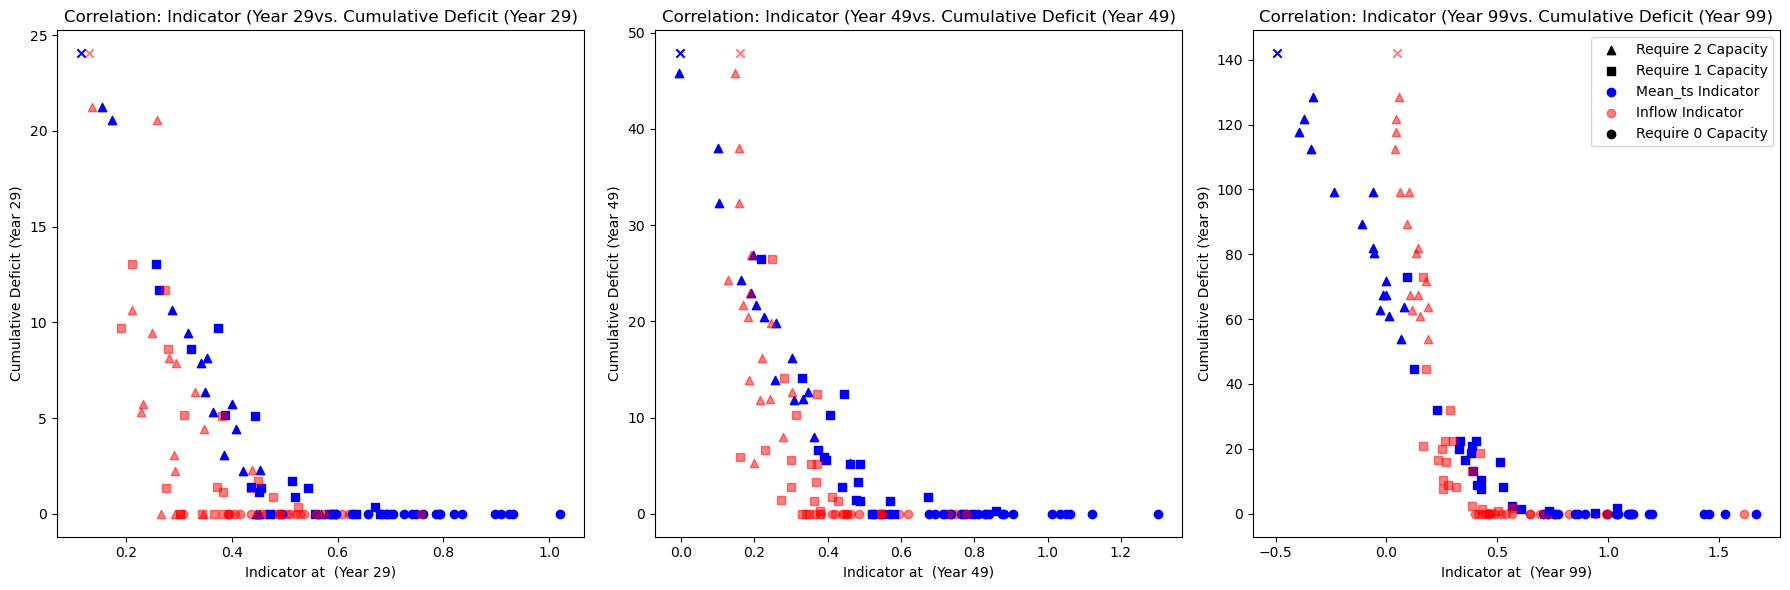

In [59]:
cor_scatter(deficit_array, mean_ts, inflow_indicators,require_0, require_1, require_2, time_horizons=[29, 49, 99])

Experiment2: BOX plot// in main.py
characteristics of climates vs 
installed capacity
planning cost
deficit 
whether flexibility built

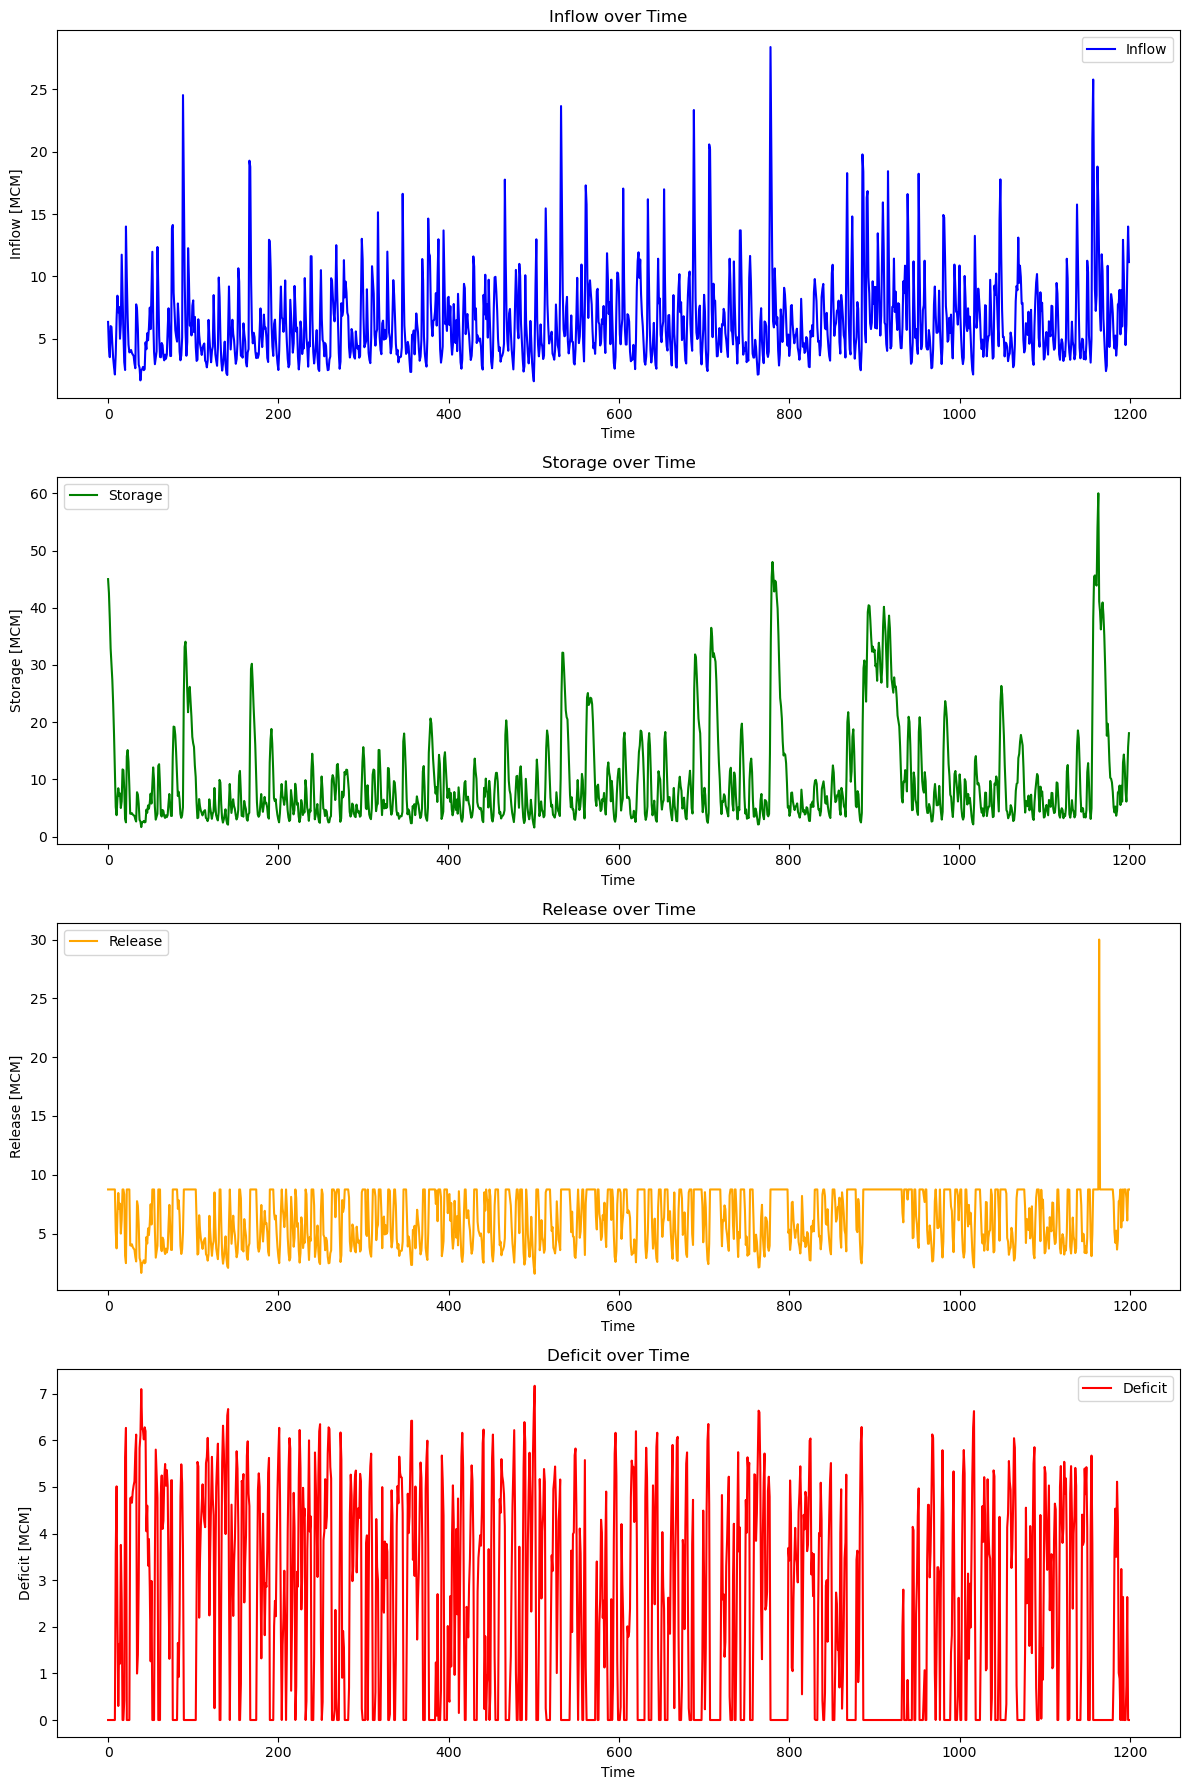

In [18]:
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(12, 18))

# Inflow over time
axs[0].plot(range(H), inflow, label='Inflow', color='blue')
axs[0].set_title('Inflow over Time')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Inflow [MCM]')
axs[0].legend()

# Storage over time
axs[1].plot(range(H + 1), s_next, label='Storage', color='green')
axs[1].set_title('Storage over Time')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Storage [MCM]')
axs[1].legend()

# Release over time
axs[2].plot(range(H), r, label='Release', color='orange')
axs[2].set_title('Release over Time')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Release [MCM]')
axs[2].legend()

# Deficit over time
axs[3].plot(range(H), deficit, label='Deficit', color='red')
axs[3].set_title('Deficit over Time')
axs[3].set_xlabel('Time')
axs[3].set_ylabel('Deficit [MCM]')
axs[3].legend()

plt.tight_layout()
plt.show()

In [6]:
config_test.climate_means.shape

(20, 400, 50)

In [8]:
inflows_path = f'{config_test.result_loc}/{config_test.syn_data_mat}'
inflows = pd.read_csv(inflows_path, header=None).T / 12
inflows

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,6.344513,6.932226,5.128224,2.070794,5.245470,4.738739,6.370856,3.258598,3.620441,6.470063,5.000936,2.213724,5.968251,10.103795,2.986674,5.115798,9.618909,4.067404,6.882883,3.351189
1,4.282917,4.175626,5.194358,3.118634,7.192597,3.626116,4.367659,4.483918,3.659608,4.126270,3.337094,6.216414,3.411177,6.879377,2.134717,3.880562,6.713946,3.107304,4.472224,3.582842
2,3.514602,3.795535,3.710805,2.610001,5.497166,3.059617,5.948867,6.677520,2.795494,3.287204,2.666687,4.324672,2.895848,4.663579,1.815166,4.091840,5.089622,2.633549,3.758718,2.716531
3,6.009692,3.742836,4.087246,2.298606,8.944766,4.276262,10.812358,6.253555,3.020901,6.346341,4.472341,7.502966,2.928708,12.662327,1.986644,5.336618,4.853558,3.503001,3.275862,2.990145
4,5.943201,5.009785,8.203654,11.195671,12.127306,4.185996,7.149946,5.428406,4.129252,5.381134,4.818908,4.898561,6.114647,9.926004,2.953985,8.191776,6.126257,4.607929,4.977531,4.147696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,4.484614,1.754769,3.437995,1.293143,2.371440,1.898734,2.078480,3.090959,1.492738,3.442850,2.009459,1.814262,1.486501,3.076319,2.147875,4.228235,6.005211,1.715197,5.271108,1.421819
1196,6.112766,1.459599,5.766531,1.207676,1.843466,1.922494,2.193387,4.729502,1.533191,3.562414,1.765470,1.625174,1.822505,3.482965,1.656054,3.689183,4.486275,1.790345,4.340400,1.254845
1197,10.421679,2.491159,5.085213,3.433701,2.672891,5.252130,3.292405,10.685612,2.378978,6.408167,6.486904,2.042978,4.929558,8.605064,1.950329,4.797367,4.686400,1.769197,5.298662,1.864271
1198,13.999226,12.491912,7.263908,5.063455,4.933335,6.734214,7.757876,8.287195,4.403685,6.423791,5.459549,4.288131,5.097758,12.296047,7.106632,11.677731,7.972480,5.333868,12.341180,5.917055


**Develop Climate Indicators from **

In [11]:
#compute previous 5 year rolling mean
rolling_means = inflows.rolling(window=60, min_periods=1).mean()
rolling_means

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,4.172095,3.293349,5.378393,5.492030,7.218458,5.525349,4.250221,3.838009,3.749993,3.278672,...,10.563772,6.096681,4.068010,7.293594,6.789128,4.748172,2.295542,3.449757,4.570001,6.031348
1,3.724692,4.114156,4.466908,4.671324,6.285595,4.602747,4.530622,4.083520,3.789868,3.062522,...,9.208883,4.924646,3.694373,6.801233,6.467446,4.073308,2.315304,2.883814,3.776242,6.332714
2,3.513294,4.322502,3.869520,4.714225,7.358839,4.296897,4.467191,3.850289,3.637808,2.868399,...,8.087914,4.217170,3.503596,6.754049,5.797600,4.086207,2.532075,2.651295,3.461979,5.765942
3,4.050688,4.689801,3.735735,4.623493,7.326286,4.237438,4.989099,3.609001,3.827409,3.349273,...,7.422464,3.849950,4.067092,6.380080,5.283079,4.074579,3.884321,2.725049,3.322528,5.781625
4,4.419175,4.911569,4.014849,6.813802,7.064107,4.416950,5.323867,5.653489,4.206171,5.343419,...,8.316708,3.645551,4.492761,6.052702,5.034174,4.146146,6.745055,2.835326,3.450465,7.016094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,4.628077,4.674202,4.575143,3.866593,5.877703,6.322304,6.062759,8.518729,5.395935,5.008846,...,4.787188,4.571827,6.599277,7.422288,10.499124,5.469782,5.864562,7.238664,5.694789,5.107322
1196,4.620088,4.703345,4.551936,3.864946,5.806928,6.256051,6.070810,8.489691,5.372527,4.985540,...,4.784378,4.568769,6.587617,7.430540,10.482796,5.491948,5.899075,7.259991,5.670397,5.114835
1197,4.584033,4.821510,4.545404,3.907028,5.655123,6.098116,6.067924,8.458677,5.330921,4.921818,...,4.772153,4.564006,6.543968,7.382493,10.011415,5.443940,5.847147,7.255801,5.638935,5.067910
1198,4.595839,4.865946,4.575378,3.955159,5.564146,5.974229,5.931033,8.233827,5.222929,4.885347,...,4.964232,4.574131,6.421142,7.407269,7.793836,5.428055,5.759384,7.161218,5.647412,5.038960


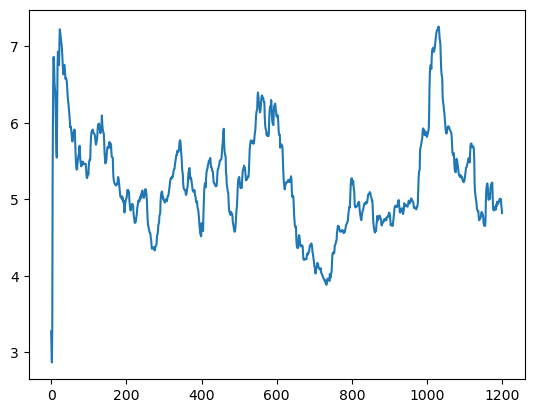

In [12]:
#plt.plot(inflows.iloc[:,9])
plt.plot(rolling_means.iloc[:,9])

In [13]:
## normalize within [0,1]

# Compute the minimum and maximum values across the DataFrame
min_value = rolling_means.iloc[60:].min().min()
max_value = rolling_means.iloc[60:].quantile(0.90).max()

print(min_value, max_value)
# Normalize the data to the range [0, 1]
normalized_inflows = (rolling_means - min_value) / (max_value - min_value)

3.1099882045966685 10.816610014701858


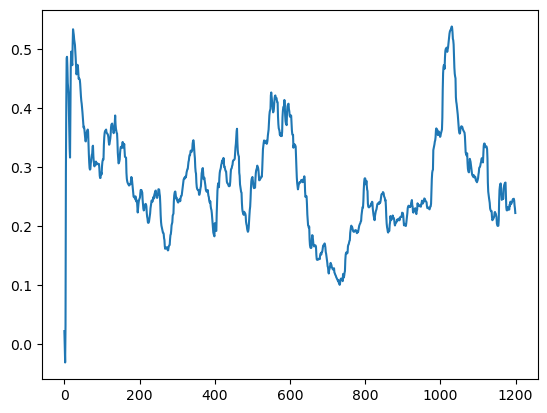

In [14]:
plt.plot(normalized_inflows.iloc[:,9])

In [10]:
#save in a csv in data
normalized_inflows.to_csv('data/5yr_GPR/inflows_indicators.csv', index=False)

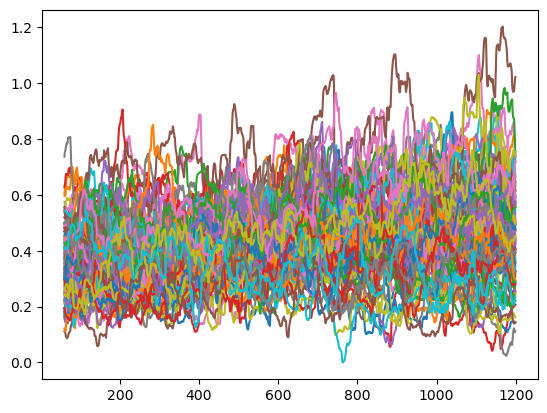

In [9]:
for i in range(100):
    plt.plot(normalized_inflows.iloc[60:,i])

**test climate indicators**

In [7]:
import numpy as np

def climate_mean_avg(climate_means, t_plus, T_convert, cycle_index):
    means = [climate_means[T_convert + t_plus, cycle_index]]
    if T_convert - 4 >= 0:
        means.extend(climate_means[T_convert - i, cycle_index] for i in range(1, 5))
    mean_avg = np.mean(means)
    return mean_avg

def normalize_climate_indicators(indicator, mean=True):
    if mean:
        min_value = -0.3
        max_value = 1.1
    else:
        min_value = 0.98
        max_value = 1.2
    normalized_indicator = (indicator - min_value) / (max_value - min_value)
    return normalized_indicator

def extract_climate_indicators(climate_means, climate_stds, t, update_freq):
    # get the year index
    T = int(t / 12)
    # which update cycle
    cycle_index = int(T / update_freq)  # updated_freg = 20

    # convert year index in climate_means file (climate_means file year start from 1875)
    T_convert = T + 125

    mean_t = climate_mean_avg(climate_means, 0, T_convert, cycle_index)
    mean_t_50 = climate_mean_avg(climate_means, 50, T_convert, cycle_index)
    std_t_50 = climate_stds[T_convert + 50, cycle_index]

    norm_mean_t = normalize_climate_indicators(mean_t, mean=True)
    norm_mean_t_50 = normalize_climate_indicators(mean_t_50, mean=True)
    norm_std_t_50 = normalize_climate_indicators(std_t_50, mean=False)

    return [norm_mean_t, norm_mean_t_50, norm_std_t_50]


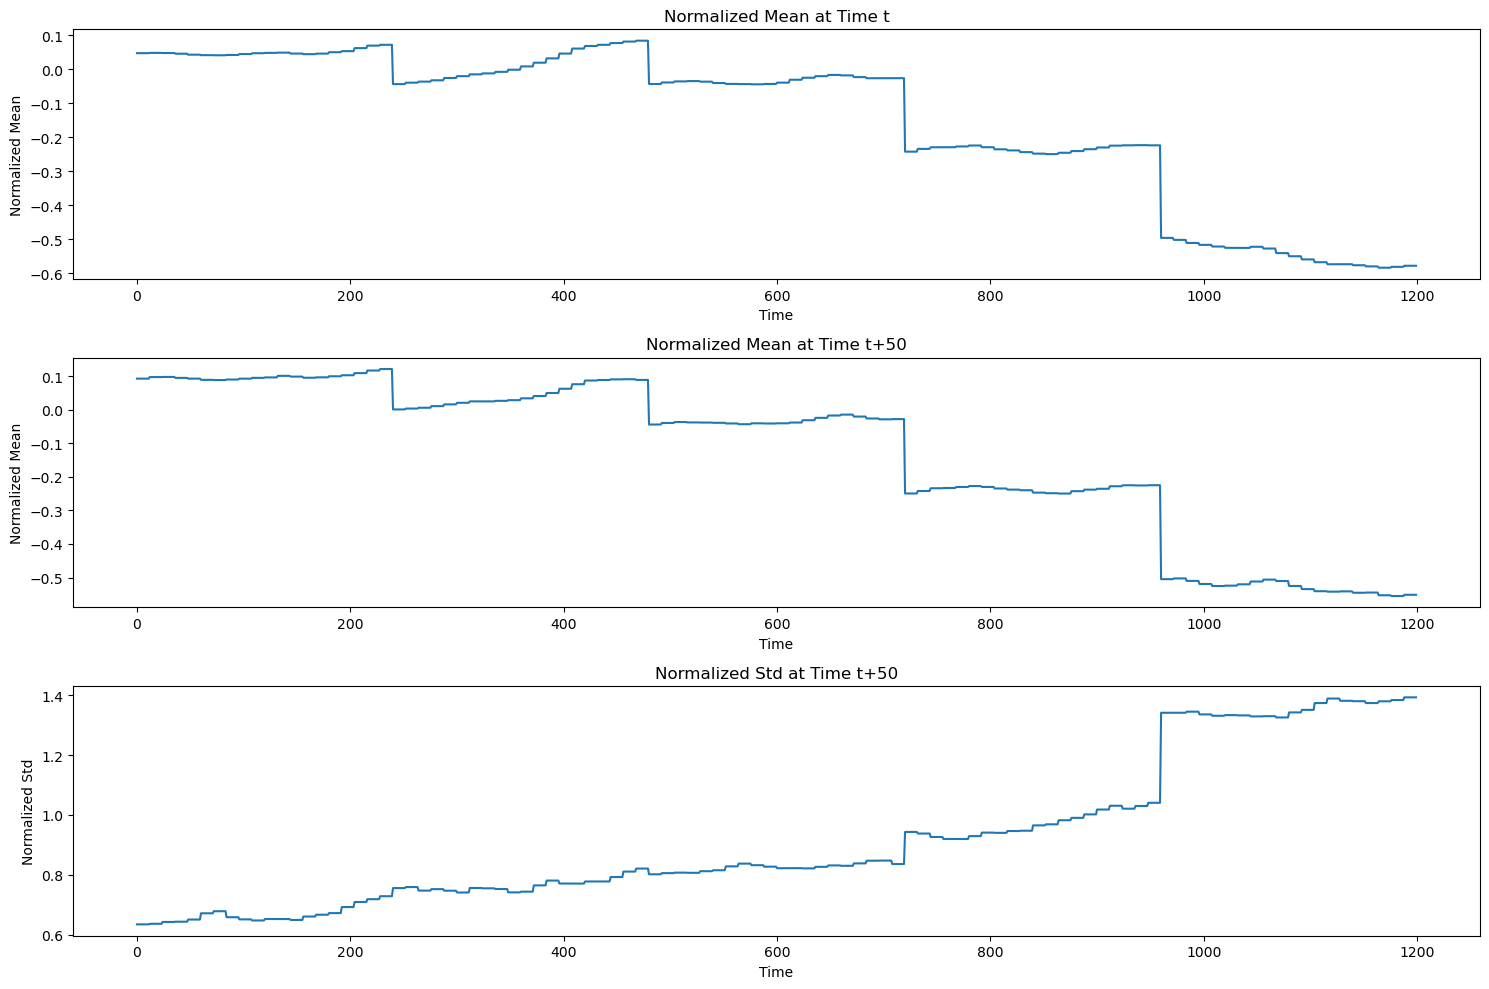

In [37]:
import matplotlib.pyplot as plt

model_id = 40
climate_means = config_test.climate_means[model_id,...] #first cliamte models
climate_stds = config_test.climate_sigmas[model_id,...]

# Assuming extract_climate_indicators, climate_mean_avg, and normalize_climate_indicators functions are defined as before

# Initialize lists to store the time series data
norm_mean_ts = []
norm_mean_t_50s = []
norm_std_t_50s = []

update_freq = 20  # Example update frequency

# Loop to calculate indicators
for t in range(1200):
    indicators = extract_climate_indicators(climate_means, climate_stds, t, update_freq)
    norm_mean_ts.append(indicators[0])
    norm_mean_t_50s.append(indicators[1])
    norm_std_t_50s.append(indicators[2])

# Time vector for plotting
time_steps = range(1200)

# Plotting
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(time_steps, norm_mean_ts, label='norm_mean_t')
plt.title('Normalized Mean at Time t')
plt.xlabel('Time')
plt.ylabel('Normalized Mean')

plt.subplot(3, 1, 2)
plt.plot(time_steps, norm_mean_t_50s, label='norm_mean_t_50')
plt.title('Normalized Mean at Time t+50')
plt.xlabel('Time')
plt.ylabel('Normalized Mean')

plt.subplot(3, 1, 3)
plt.plot(time_steps, norm_std_t_50s, label='norm_std_t_50')
plt.title('Normalized Std at Time t+50')
plt.xlabel('Time')
plt.ylabel('Normalized Std')

plt.tight_layout()
plt.show()




**test pipe simulation**


In [36]:
import matplotlib
import numpy as np
import pandas as pd
from pipe_simulation import Pipe
from pipesim_individual import Pipe_sim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy.matlib as mat
import pickle

In [ ]:
run_bayes = True
label = label = '041102'
config_bayesDPS = f"bayes_{label}"
config_normDPS = f"norm_{label}"


if run_bayes:
    config_name = config_bayesDPS
    config = Config(run_bayes)
else:
    config_name= config_normDPS
    config = Config(run_bayes)



solution_file_path = f'results/results_{config_name}.dat'
# Read the solution from the file
with open(solution_file_path, 'rb') as f:
    solution = pickle.load(f)

objs_eff = solution.objs
log = solution.log[0]
best_solution = solution.best_solution

In [ ]:
compute_objs(param, opt_par, config, s, config_name)
plot_trajectories(param, opt_par, config, s, config_name):  #decide simulate under which inflow
sns.set_style('darkgrid')

sim = Pipe_sim(opt_par, config)
traj = sim.simulation(param, s)

**norm cliamte indicators**

In [5]:
model_id = 8
climate_means = config_test.climate_means[model_id,...] #first cliamte models
climate_stds = config_test.climate_sigmas[model_id,...]

In [6]:
climate_means.shape #  (400,6) for 5 update cycle, plot 2000-2100 means as lines, year 2000 is index 125

# (80, 6) for 5 yr GPR

(80, 6)

In [8]:
len(np.arange(1875,2000, 1))

125

In [7]:
len(np.arange(1875,2000, 5))

25

In [12]:
years= np.arange(1875,2105, 5)
years[45]

2100

In [14]:
config_test.climate_means[:,25:45,:4].shape

(100, 20, 4)

In [16]:
# find the min, max value
#means_mat = config_test.climate_means[:,125:225,:] #all synthetic time sereis, all updates cycles. year 2000-2100  # this is for annual GPR
#stds_mat = config_test.climate_sigmas[:,125:225,:]

means_mat = config_test.climate_means[:,25:45,:4] #all synthetic time sereis, first 4 update cycles. year 2000-2100  # this is for 5 year GPR
stds_mat = config_test.climate_sigmas[:,25:45,:4]

print(f'95% percentile for cliamte means is {np.percentile(means_mat, 95)}')
print(f'5 % percentile for cliamte means is {np.percentile(means_mat, 5)}')

print(f'95% percentile for cliamte stds is {np.percentile(stds_mat, 95)}')
print(f'5 % percentile for cliamte stds is {np.percentile(stds_mat, 5)}')

95% percentile for cliamte means is 1.0371840252606066
5 % percentile for cliamte means is -0.33464445122158787
95% percentile for cliamte stds is 0.7857194304773318
5 % percentile for cliamte stds is 0.5149975201728985


Text(0.5, 1.0, 'cliamte mean indicators of id_4')

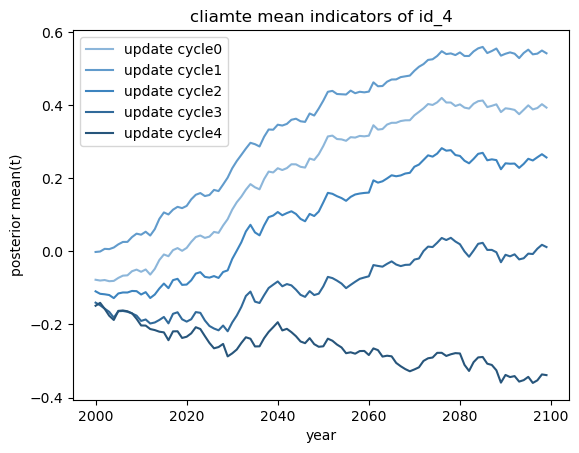

In [49]:
model_id = 4
climate_means = config_test.climate_means[model_id,...] #first cliamte models
climate_stds = config_test.climate_sigmas[model_id,...]
colors = ["#8cb6da", "#619bcc","#3d84bf", "#316a9a", "#27557b"]

years = np.arange(2000,2100)
plt.figure()
for i in range(5):
    plt.plot(years, climate_means[125:225,i], color = colors[i],  label = f'update cycle{i}')
plt.ylabel("posterior mean(t)")
plt.xlabel("year")
plt.legend()
plt.title(f'cliamte mean indicators of id_{model_id}')

Text(0.5, 1.0, 'cliamte std indicators of id_15')

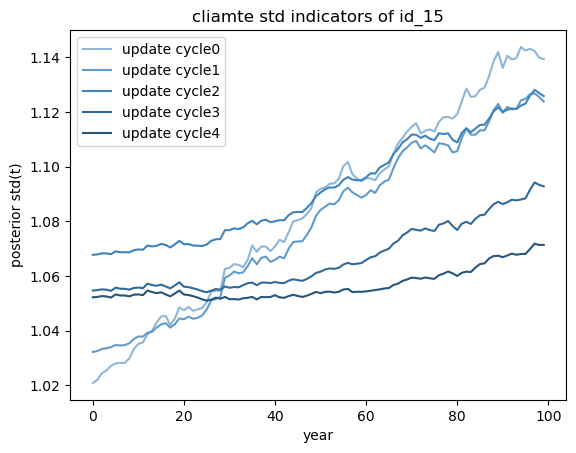

In [45]:
model_id = 15
climate_means = config_test.climate_means[model_id,...] #first cliamte models
climate_stds = config_test.climate_sigmas[model_id,...]

colors = ["#8cb6da", "#619bcc","#3d84bf", "#316a9a", "#27557b"]
plt.figure()
for i in range(5):
    plt.plot(climate_stds[125:225,i], color = colors[i], label = f'update cycle{i}')
plt.ylabel("posterior std(t)")
plt.xlabel("year")
plt.legend()
plt.title(f'cliamte std indicators of id_{model_id}')

In [53]:
# find the min, max value
#means_mat = config_test.climate_means[:,125:225,:] #all synthetic time sereis, all updates cycles. year 2000-2100  # this is for annual GPR
#stds_mat = config_test.climate_sigmas[:,125:225,:]

means_mat = config_test.climate_means[:,125:225,:] #all synthetic time sereis, all updates cycles. year 2000-2100  # this is for annual GPR
stds_mat = config_test.climate_sigmas[:,125:225,:]

print(f'95% percentile for cliamte means is {np.percentile(means_mat, 95)}')
print(f'5 % percentile for cliamte means is {np.percentile(means_mat, 5)}')

print(f'95% percentile for cliamte stds is {np.percentile(stds_mat, 95)}')
print(f'5 % percentile for cliamte stds is {np.percentile(stds_mat, 5)}')


95% percentile for cliamte means is 1.097603742792379
5 % percentile for cliamte means is -0.2656213698590141
95% percentile for cliamte stds is 1.173842791951683
5 % percentile for cliamte stds is 0.9800395588196498


In [71]:
#write a function to norm its climate indicators 
def normalize_climate_indicators(indicator, mean = True ):

    if mean == True:

        min_value = - 0.3
        max_value = 1.1
    
    else:
        min_value = 0.98
        max_value = 1.2
    normalized_indicator = (indicator - min_value) / (max_value - min_value)
    return normalized_indicator

Text(0.5, 1.0, 'normalized cliamte mean indicators of model 2')

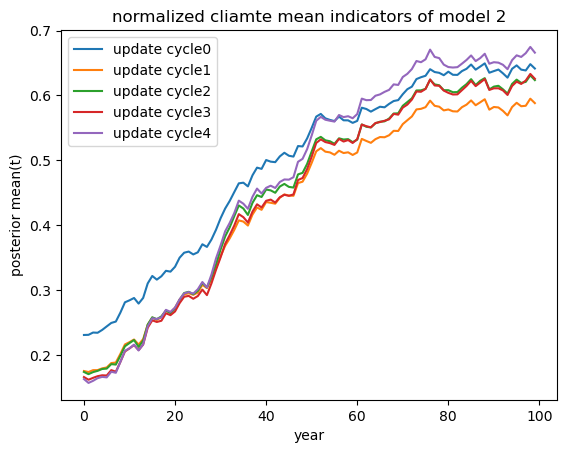

In [73]:
model_id = 2
climate_means = config_test.climate_means[model_id,...] #first cliamte models
climate_stds = config_test.climate_sigmas[model_id,...]


plt.figure()
for i in range(5):
    plt.plot(normalize_climate_indicators(climate_means[125:225,i], mean = True), label = f'update cycle{i}')
plt.ylabel("posterior mean(t)")
plt.xlabel("year")
plt.legend()
plt.title(f'normalized cliamte mean indicators of model {model_id}')

Text(0.5, 1.0, 'normalized cliamte std indicators of model 2')

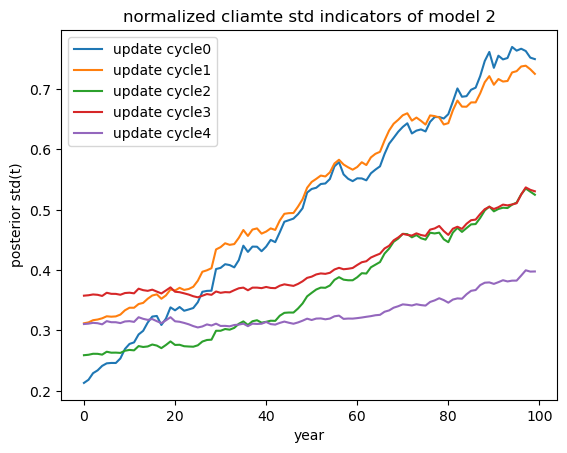

In [75]:
model_id = 2
climate_means = config_test.climate_means[model_id,...] #first cliamte models
climate_stds = config_test.climate_sigmas[model_id,...]


plt.figure()
for i in range(5):
    plt.plot(normalize_climate_indicators(climate_stds[125:225,i], mean = False), label = f'update cycle{i}')
plt.ylabel("posterior std(t)")
plt.xlabel("year")
plt.legend()
plt.title(f'normalized cliamte std indicators of model {model_id}')

In [4]:
inflows

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,4.172095,3.293349,5.378393,5.492030,7.218458,5.525349,4.250221,3.838009,3.749993,3.278672,...,10.563772,6.096681,4.068010,7.293594,6.789128,4.748172,2.295542,3.449757,4.570001,6.031348
1,3.277289,4.934963,3.555423,3.850618,5.352732,3.680144,4.811024,4.329030,3.829743,2.846373,...,7.853994,3.752610,3.320736,6.308871,6.145763,3.398445,2.335066,2.317871,2.982483,6.634079
2,3.090499,4.739194,2.674744,4.800027,9.505328,3.685198,4.340328,3.383827,3.333688,2.480151,...,5.845976,2.802219,3.122042,6.659681,4.457907,4.112004,2.965617,2.186257,2.833452,4.632397
3,5.662870,5.791699,3.334382,4.351299,7.228624,4.059062,6.554823,2.885137,4.396213,4.791896,...,5.426113,2.748290,5.757582,5.258173,3.739517,4.039696,7.941059,2.946309,2.904174,5.828677
4,5.893125,5.798641,5.131302,15.575036,6.015392,5.134997,6.662937,13.831441,5.721219,13.320002,...,11.893683,2.827954,6.195436,4.743193,4.038553,4.432415,18.187992,3.276434,3.962216,11.953967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2.082317,3.256626,2.675088,1.897602,2.542727,3.935686,3.503974,3.537290,1.822166,2.612796,...,2.697117,2.175669,4.367116,3.733321,3.976036,3.304767,4.271407,4.582779,3.935345,3.863120
1196,2.317069,4.633578,2.896901,1.807078,2.314412,3.750722,3.012682,2.647914,2.268523,2.330282,...,3.932132,2.831826,3.602554,4.103881,3.573879,3.641932,4.143722,4.607992,2.747376,2.664185
1197,3.467527,10.596170,4.092997,5.275504,4.649274,3.789358,3.446141,3.061344,6.677320,3.117305,...,4.049623,3.178276,7.990679,4.764734,4.537036,4.323536,2.754415,3.143545,3.496613,3.415505
1198,8.479970,8.851522,8.325273,7.861476,7.238413,10.159027,4.402331,10.471149,6.716854,6.440045,...,20.503172,4.226156,7.401417,12.708155,8.816768,7.455319,3.728872,4.303086,9.357497,6.138940


**test learning of Prep and inflow**

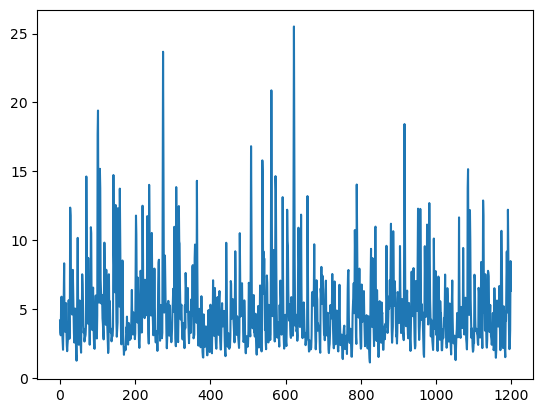

In [12]:
plt.plot(np.arange(1200), inflows.iloc[:,0])

In [5]:
def detrend(x, frac):
    """
    Detrend a time series using LOESS.
    
    Parameters:
    - x: The time series data (list or numpy array).
    - frac: The fraction of the data used when estimating each y-value in the LOWESS.  #locally weighted scatterplot smoothing
    
    Returns:
    - A DataFrame with the trend line and detrended data.
    """
  
    # Generate an index array
    index = np.arange(len(x))
    
    # Apply LOWESS smoothing
    # The 'frac' parameter controls the degree of smoothing
    lowess_result = lowess(x, index, frac=frac)
    
    # Extract smoothed values
    x_smoothed = lowess_result[:, 1]
    
    # Calculate the detrended series
    x_detrended = x - x_smoothed
    
    # Create a DataFrame to store the trend line and detrended data
    detrend_df = pd.DataFrame({'trend_line': x_smoothed, 'detrend': x_detrended})
    
    return detrend_df

Text(0.5, 1.0, 'sample of monthly inflow time series')

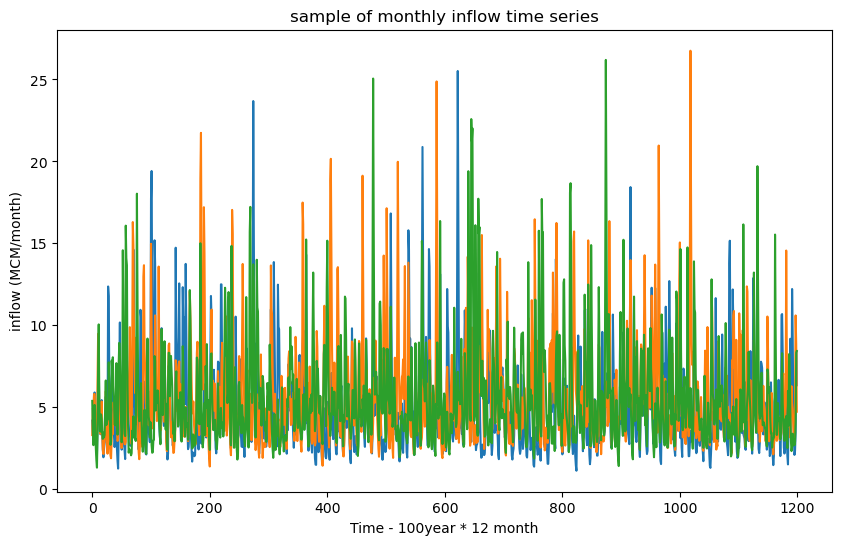

In [14]:
plt.figure(figsize = (10,6))
for i in range(3):
    plt.plot(np.arange(1200), inflows.iloc[:,i])
plt.xlabel("Time - 100year * 12 month")
plt.ylabel("inflow (MCM/month)")
plt.title("sample of monthly inflow time series")

(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)
(100,)


Text(0.5, 1.0, 'sample of annual inflow time series trends')

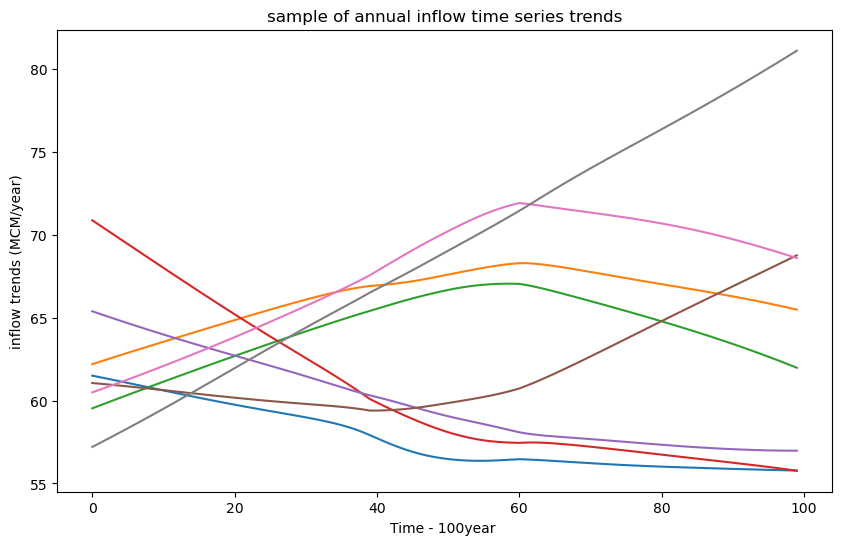

In [20]:
plt.figure(figsize = (10,6))
for i in range(8):
    inflow = inflows.iloc[:,i].values
    annual_inflow = np.sum(inflow.reshape(100,12), axis = 1)
    print(annual_inflow.shape)
    de_ann = detrend(annual_inflow, 0.8)["trend_line"]
    plt.plot(np.arange(100), de_ann)
plt.xlabel("Time - 100year ")
plt.ylabel("inflow trends (MCM/year)")
plt.title("sample of annual inflow time series trends")

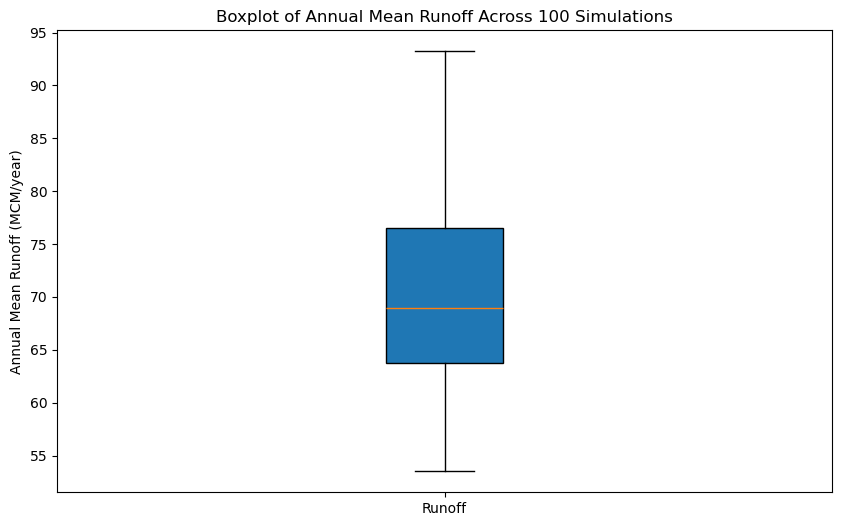

In [23]:
#compute distributions of mean annual runoff across 100 simulations
#np.mean(inflows)*12
means = []
for i in range(100):
    means.append(np.mean(inflows.iloc[:,i].values) * 12)
#means
plt.figure(figsize=(10, 6))
plt.boxplot(means, vert=True, patch_artist=True)  # 'vert=True' makes the boxplot vertical
plt.title('Boxplot of Annual Mean Runoff Across 100 Simulations')
plt.ylabel('Annual Mean Runoff (MCM/year)')
plt.xticks([1], ['Runoff'])  # Only one category
plt.show()


In [16]:
climate_means = config_test.climate_means[0,...]
climate_stds = config_test.climate_sigmas[0,...]


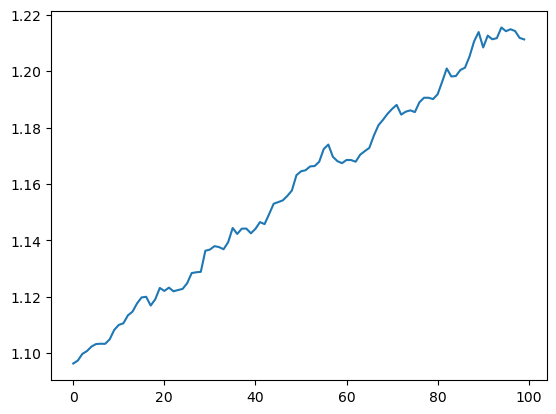

In [22]:
plt.plot(climate_stds[125:225,0])

Smaller chunk testing  
1. reservoir simulate function
2. test rbf function
3. test policy2action function

Test reservoir simulation function

In [5]:
from numba import njit
@njit
def nsim_equiv_res(s, u, n, s_max):
    # extremely fast reservoir mass balance computation
    r         = max(0, min(u, s))
    s_        = s + n - r
    s_        = max(0, min(s_, s_max ))

    return s_, r

S0 = config_test.initial_storage
hedge_param = config_test.hedge_param
smax = config_test.smax
print(S0, hedge_param, smax)

H = config_test.H
deficit = np.zeros(H)
Jdeficit = np.zeros(H)
s_next = np.zeros(H+1)  #storage
s_next[0] = config_test.initial_storage
r = np.zeros(H)

inflow = config_test.inflows.iloc[:,0].values
#simulation
for t in range(H) : # simulate 100-year monthly horizon

    demand_ = config_test.demand 
    ############## system already has a reservoir , simulate reservoir mass balance (simple hedge rule)
        
    # reservoir mass balance (simple hedging rule)  # or just release the water available (ref: 266G)
    hedge = config_test.hedge_param * s_next[t]
    flood = 10 * s_next[t] *(1/2 - demand_ /smax) - 9*(smax/2 - demand_) + demand_
    u = max(min(hedge,demand_), flood)

    #reservoir mass balance
    s_, release = nsim_equiv_res(s_next[t], u, inflow[t], smax)
    s_next[t+1] = s_
    r[t] = release
    deficit[t]= max(0, demand_ - release)
    if deficit[t] < 1e-4:
        deficit[t] = 0

    Jdeficit[t] = deficit[t] ** 2

15 15 60


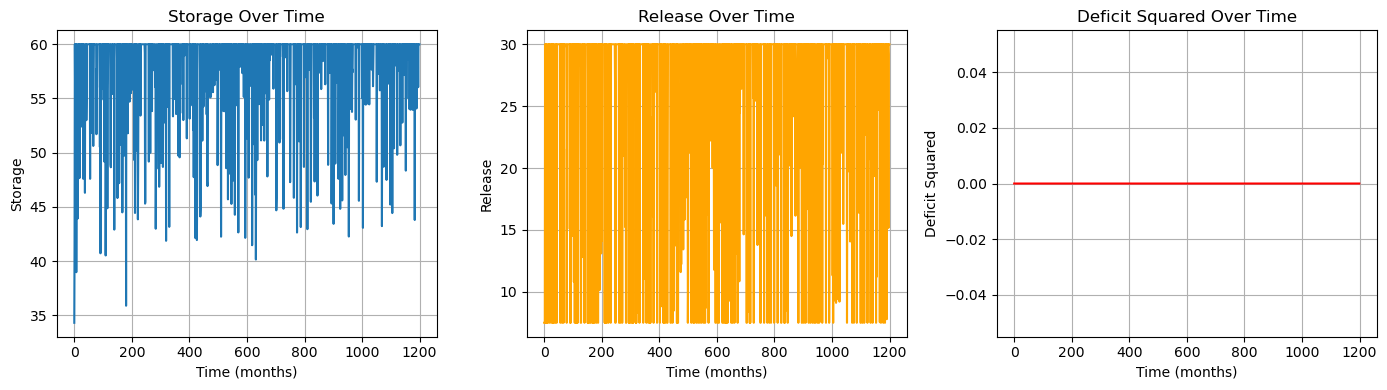

In [6]:
t = np.arange(H)  # Time steps

# s_next vs. t
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.plot(t, s_next[1:], label='Storage')
plt.xlabel('Time (months)')
plt.ylabel('Storage')
plt.title('Storage Over Time')
plt.grid(True)

# r vs. t
plt.subplot(1, 3, 2)
plt.plot(t, r, label='Release', color='orange')
plt.xlabel('Time (months)')
plt.ylabel('Release')
plt.title('Release Over Time')
plt.grid(True)

# Jdeficit vs. t
plt.subplot(1, 3, 3)
plt.plot(t, Jdeficit, label='Deficit^2', color='red')
plt.xlabel('Time (months)')
plt.ylabel('Deficit Squared')
plt.title('Deficit Squared Over Time')
plt.grid(True)

plt.tight_layout()
plt.show()


test policy2action function

In [14]:
fixed_cost = 200 #per MCM of capacity
flex_cost = 250 #per MCM of capacity
flex_expand = 80  #per MCM of expanding capacity
fix_built = False
flex_built = False

def map_capacity_to_built( capacity,lower_thres ,upper_thres, seg):

    [s_size, m_size, l_size] = [10,30,50]

    # Ensure the capacity falls within the expected range
    if not (lower_thres < capacity <= upper_thres):
        raise ValueError(f"Capacity {capacity} is out of the expected range.")

# Determine capacity_to_built based on the capacity range using a conditional expression
        # Determine capacity_to_built based on the capacity range using a conditional expression
    if lower_thres < capacity <= lower_thres + seg:
        return s_size
    elif lower_thres + seg < capacity <= lower_thres + seg * 2:
        return m_size
    elif lower_thres + seg * 2 < capacity <= upper_thres:
        return l_size
    else:
        return None



def Policy2Action(capacity, capa_installed, fix_built, flex_built):
        
    #### evaluate output from rbf (0-1):
    seg = 1/7
    planning_cost = 0 
    
    if capacity <= seg:  # do nothing
        pass

    elif seg < capacity <= seg*4 :    # install fix pipe

        capa_to_built = map_capacity_to_built(capacity, seg ,seg*4, seg)

        if not fix_built and not flex_built : 

            fix_built = True
            capa_installed = capa_to_built
            planning_cost = fixed_cost * capa_installed

    elif  seg*4 < capacity <= seg*7 :  #install flex pipe

        capa_to_built = map_capacity_to_built(capacity, seg*4 ,seg*7, seg)

        if not fix_built:  

            if not flex_built : #build pipe the very first time
                
                flex_built = True
                capa_installed = capa_to_built
                planning_cost = flex_cost * capa_installed
            
            elif capa_to_built > capa_installed:
                    planning_cost = flex_expand *(capa_to_built -capa_installed )
                    capa_installed = capa_to_built

    return planning_cost, capa_installed, fix_built, flex_built

In [26]:
capacity = 0.9
capa_installed = 10
fix_built = False
flex_built = False

planning_cost, capa_installed, fix_built, flex_built = Policy2Action(capacity, capa_installed, fix_built, flex_built)

print(planning_cost, capa_installed, fix_built, flex_built)

12500 50 False True


test rbf function

In [37]:
import numpy as np

class node_param:
    def __init__(self):
        self.c = []
        self.b = []
        self.w = []


#class ncRBF(object):

def get_output(inp, param, lin_param, N, M, K):
    # get layers charateristics
    # N = self.N # number of nodes in hidden layer
    # M = self.M # number of inputs
    # K = self.K # number of outputs

    phi = []
    o = []
    output = []

    for j in range(N):
        bf = 0

        for i in range(M):
            num = (inp[i] - param[j].c[i])*(inp[i] - param[j].c[i])
            den = (param[j].b[i]*param[j].b[i])

            if den < pow(10,-6):
                den = pow(10,-6)

            bf = bf + num / den

        phi.append( np.exp(-bf) )     # each element in the phi vector is the output of jth rbf in the hidden layer

    for k in range(K):
        o = lin_param[k]
        for j in range(N):
            o = o + param[j].w[k]*phi[j]   # compute the weighted sum of the outputs from the rbfs. param[j].w[k] is the weight of node j for output k

        print(o)
        if o > 1:
            o = 1.0
        if o < 0:
            o = 0.0     # make sure the output is in [0,1]

        output.append(o)

    return output


def set_param(policies, N, M, K):

    param_string = policies 
    count = 0
    lin_param = []
    param = []


    # linear parameters. As many as the outputs
    for k in range(K):
        lin_param.append(param_string[count])
        count += 1


    # RBF paramters
    for i in range(N): # nodes

        node = node_param()  #for each node,an instance of 'node_param' is created

        for j in range(M):
            node.c.append(param_string[count]) # center
            count += 1
            node.b.append(param_string[count]) # radius
            count += 1

        for k in range(K):
            node.w.append(param_string[count]) # output weight
            count += 1

        param.append(node)


    return param,lin_param

Each node has M centers, M radii, and K weights. Thus, each node has M + M + K = 2M + K parameters.

With N nodes, the total parameters for all nodes are N * (2M + K).

Adding the K linear parameters, the total length of P is N * (2M + K) + K.  

For N = 5, M = 3, and K = 1:

Total parameters for all nodes = 5 * (2*3 + 1) = 5 * 7 = 35.

Adding the K linear parameters, the total length of P = 35 + 1 = 36

In [58]:
 #extract and interpret RBF paramters from policy param list P
N = 5   #of hidden nodes (basis) N = M+ K + 1
M = 3   #of inputs
K = 1   #of outputs

# Calculate the length of P
P_length = N * (2*M + K) + K

# Generate a random P policy for testing 
P = np.random.rand(P_length)
print("length of P vector:", len(P))

indicators = [0.1, 0.2, 0.3]
param, lin_param = set_param(P, N, M, K)
capacity = get_output(indicators, param, lin_param, N, M, K)
print('lin_param:', lin_param)
print(capacity)

length of P vector: 36
1.6140552225885345
lin_param: [0.8796348967818326]
[1.0]


In [8]:
opt_par = OptimizationParameters()
pipe_test = Pipe(opt_par,config_test)

TypeError: Pipe.__init__() missing 2 required positional arguments: 'opt_par' and 'config'

In [2]:
#result_loc = 'C:/Users/mofan/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/synthetic generator/results'
result_loc = '/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/synthetic generator/results'
mu_mat = 'mu_mat.npz'
std_mat = 'std_mat.npz'
syn_data_mat = 'synthetic_data_mat.csv'


inflows = pd.read_csv(f'{result_loc}/{syn_data_mat}')
loaded_mu = np.load(f'{result_loc}/{mu_mat}')['mu']
loaded_std = np.load(f'{result_loc}/{std_mat}')['std']

In [28]:
type(inflows.iloc[:,0].values)

numpy.ndarray

#shape of mu_mat (100, 80, 6)     80*5 = 400year (1875 - 2225), 6 update cycles
#shape of std_mat (100, 80, 6)

In [3]:
# Check the dimensions
print("Dimensions of loaded_mu:", loaded_mu.shape)

# Check the type
print("Type of loaded_mu:", type(loaded_mu))

Dimensions of loaded_mu: (100, 80, 6)
Type of loaded_mu: <class 'numpy.ndarray'>


In [4]:
loaded_mu[0,...].shape

(80, 6)

In [5]:
N_total = np.arange(1875,2275,5)
#check index for year = 2000
index_2000 = np.where(N_total == 2000)[0]
index_2000

array([25])

In [12]:
# input. cliamte_means is i slice of loaded_mu, 2d matrix for ith simulation
# input. t: simulation time step in months.
# output: climate indicators: mean(t), mean(t+50), std(t+50)

def extract_climate_indicators(cliamte_means, cliamte_stds, t, updated_freg):

    # get the year index
    T = int(t/12)
    #which update cycle
    cycle_index = int(T/updated_freg)    # updated_freg = 25

    #convert year index in cliamte_means file (calimte_means file year start from 1875)
    T_convert = int(T/5) + 25
    mean_t = cliamte_means[T_convert, cycle_index]
    mean_t_50 = cliamte_means[T_convert + 10, cycle_index]
    std_t_50 = cliamte_stds[T_convert + 10, cycle_index]

    return mean_t, mean_t_50,std_t_50 


In [13]:
t = 62   #62th month,year 5
extract_climate_indicators(loaded_mu[0,...], loaded_std[0,...], t, 25)

(-0.1776755880544934, 0.1364236640516683, 0.7452967801127919)

In [21]:
# T = int(62/12) = 5
# cycle_index = int(5/25) = 0
# year_index in climate_means files : year2000 = index 25, T_convert = int(5/5) + 25 = 26
print(loaded_mu[0,...][26, 0])
print(loaded_std[0,...][36,0])

-0.1776755880544934
0.7452967801127919
